In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
sns.set_theme()
gc.enable()

# Aggregating Bureau Balance

In [2]:
bureau_balance=pd.read_csv('bureau_balance.csv')
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [3]:
bureau_balance.shape

(27299925, 3)

In [4]:
bureau_balance['STATUS'].unique()

array(['C', '0', 'X', '1', '2', '3', '5', '4'], dtype=object)

In [5]:
'''
for each bureau loan, this step presents the count of different types of status present
'''
bureau_balance_agg=bureau_balance[['SK_ID_BUREAU', 'STATUS']].value_counts().unstack().replace(np.nan, 0).reset_index()
bureau_balance_agg.head()

STATUS,SK_ID_BUREAU,0,1,2,3,4,5,C,X
0,5001709,0.0,0.0,0.0,0.0,0.0,0.0,86.0,11.0
1,5001710,5.0,0.0,0.0,0.0,0.0,0.0,48.0,30.0
2,5001711,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,5001712,10.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0
4,5001713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0


In [6]:
'''
adding total column
'''
bureau_balance_agg['TOTAL']=bureau_balance_agg.drop('SK_ID_BUREAU', axis=1).sum(axis=1)
bureau_balance_agg.head()

STATUS,SK_ID_BUREAU,0,1,2,3,4,5,C,X,TOTAL
0,5001709,0.0,0.0,0.0,0.0,0.0,0.0,86.0,11.0,97.0
1,5001710,5.0,0.0,0.0,0.0,0.0,0.0,48.0,30.0,83.0
2,5001711,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
3,5001712,10.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,19.0
4,5001713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,22.0


In [7]:
'''
proper renaming of the columns
'''
bureau_balance_agg.rename(columns={'0': 'STATUS_NO_DPD', '1': 'STATUS_<31DPD', '2': 'STATUS_<61DPD', '3': 'STATUS_<91DPD', 
                                   '4': 'STATUS_<121DPD', '5': 'STATUS_>120DPD',
                                   'C': 'STATUS_CLOSED', 'X': 'STATUS_NA', 'TOTAL': 'STATUS_TOTAL'}, inplace=True)
bureau_balance_agg.head()

STATUS,SK_ID_BUREAU,STATUS_NO_DPD,STATUS_<31DPD,STATUS_<61DPD,STATUS_<91DPD,STATUS_<121DPD,STATUS_>120DPD,STATUS_CLOSED,STATUS_NA,STATUS_TOTAL
0,5001709,0.0,0.0,0.0,0.0,0.0,0.0,86.0,11.0,97.0
1,5001710,5.0,0.0,0.0,0.0,0.0,0.0,48.0,30.0,83.0
2,5001711,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
3,5001712,10.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,19.0
4,5001713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,22.0


# Dealing with main Bureau data

In [8]:
del bureau_balance
bureau=pd.read_csv('bureau.csv')
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


#### Merging with aggregated bureau balance data

In [9]:
'''
this highlights that 17,16,428 bureau loans present, bureau balance only has recors of 8,17,395 of them
'''
bureau['SK_ID_BUREAU'].unique().shape, bureau_balance_agg['SK_ID_BUREAU'].unique().shape

((1716428,), (817395,))

In [10]:
'''
merging bureau and bureau balance data based on bureau id
'''
combined_data=pd.merge(left=bureau, right=bureau_balance_agg, how='left', on='SK_ID_BUREAU')
combined_data.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,...,AMT_ANNUITY,STATUS_NO_DPD,STATUS_<31DPD,STATUS_<61DPD,STATUS_<91DPD,STATUS_<121DPD,STATUS_>120DPD,STATUS_CLOSED,STATUS_NA,STATUS_TOTAL
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
'''
segregating columns into numerical and categorical
'''
numerical_features=combined_data.select_dtypes(exclude='object').columns
categorical_features=combined_data.columns.difference(numerical_features)

In [12]:
main_data_id_target=pd.read_csv('application_train.csv', usecols=['SK_ID_CURR', 'TARGET'])
main_data_id_target.head()

,SK_ID_CURR,TARGET
0,100002,1
1,100003,0
2,100004,0
3,100006,0
4,100007,0


## Numerical Features

In [13]:
'''
numerical frame consists of bureau data which only numerical comulumns
'''
numerical_frame=combined_data[numerical_features].copy()
numerical_frame.head()

,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,...,AMT_ANNUITY,STATUS_NO_DPD,STATUS_<31DPD,STATUS_<61DPD,STATUS_<91DPD,STATUS_<121DPD,STATUS_>120DPD,STATUS_CLOSED,STATUS_NA,STATUS_TOTAL
0,215354,5714462,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,215354,5714463,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,215354,5714464,-203,0,528.0,NaN,NaN,0,464323.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,215354,5714465,-203,0,NaN,NaN,NaN,0,90000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,215354,5714466,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
'''
bureau balance has data for 3,05,811 current loans
'''
numerical_frame['SK_ID_CURR'].unique().shape

(305811,)

In [15]:
'''
replacing nans appropriately
'''
numerical_frame.replace(to_replace={'STATUS_NO_DPD': np.nan, 'STATUS_<31DPD': np.nan, 'STATUS_<61DPD': np.nan,'STATUS_<91DPD': np.nan,        
                                    'STATUS_<121DPD': np.nan, 'STATUS_>120DPD': np.nan, 'STATUS_CLOSED': np.nan, 'STATUS_NA': np.nan,           
                                    'STATUS_TOTAL': np.nan}, value=0, inplace=True)
numerical_frame.isnull().sum()

SK_ID_CURR                      0
SK_ID_BUREAU                    0
DAYS_CREDIT                     0
CREDIT_DAY_OVERDUE              0
DAYS_CREDIT_ENDDATE        105553
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_MAX_OVERDUE    1124488
CNT_CREDIT_PROLONG              0
AMT_CREDIT_SUM                 13
AMT_CREDIT_SUM_DEBT        257669
AMT_CREDIT_SUM_LIMIT       591780
AMT_CREDIT_SUM_OVERDUE          0
DAYS_CREDIT_UPDATE              0
AMT_ANNUITY               1226791
STATUS_NO_DPD                   0
STATUS_<31DPD                   0
STATUS_<61DPD                   0
STATUS_<91DPD                   0
STATUS_<121DPD                  0
STATUS_>120DPD                  0
STATUS_CLOSED                   0
STATUS_NA                       0
STATUS_TOTAL                    0
dtype: int64

### Agregating numerical data

In [16]:
'''
aggregating all numerical columns with count, min, max and median along with renaming appropriately
'''
bureau_agg=numerical_frame.groupby(by='SK_ID_CURR').agg(func=['count', 'min', 'max', 'median'])
cols=pd.Index(['_'.join(val) for val in bureau_agg.columns.to_flat_index()])
bureau_agg.columns=cols
bureau_agg.shape

(305811, 88)

In [17]:
'''
dropping columns appropriately
'''
drop_cols=['_'.join([val, 'count']) for val in numerical_frame.columns.difference(['SK_ID_CURR', 'SK_ID_BUREAU'])]
drop_cols+=['SK_ID_BUREAU_min', 'SK_ID_BUREAU_max', 'SK_ID_BUREAU_median']

bureau_agg.drop(labels=drop_cols, axis=1, inplace=True)
bureau_agg.reset_index(inplace=True)
bureau_agg.shape

(305811, 65)

#### Combining target to bureau agg

In [18]:
bureau_agg_target=pd.merge(left=bureau_agg, right=main_data_id_target, on='SK_ID_CURR', how='inner')
bureau_agg_target.shape

(263491, 66)

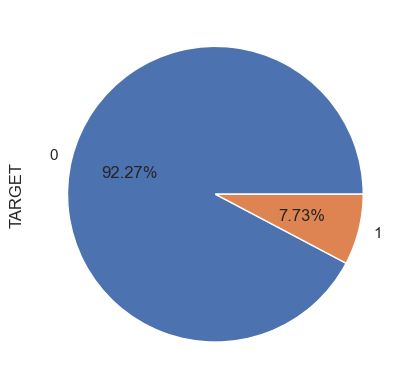

In [19]:
'''
distribution of target in the aggregated bureau data
'''
bureau_agg_target['TARGET'].value_counts().plot.pie(autopct='%1.2f%%');

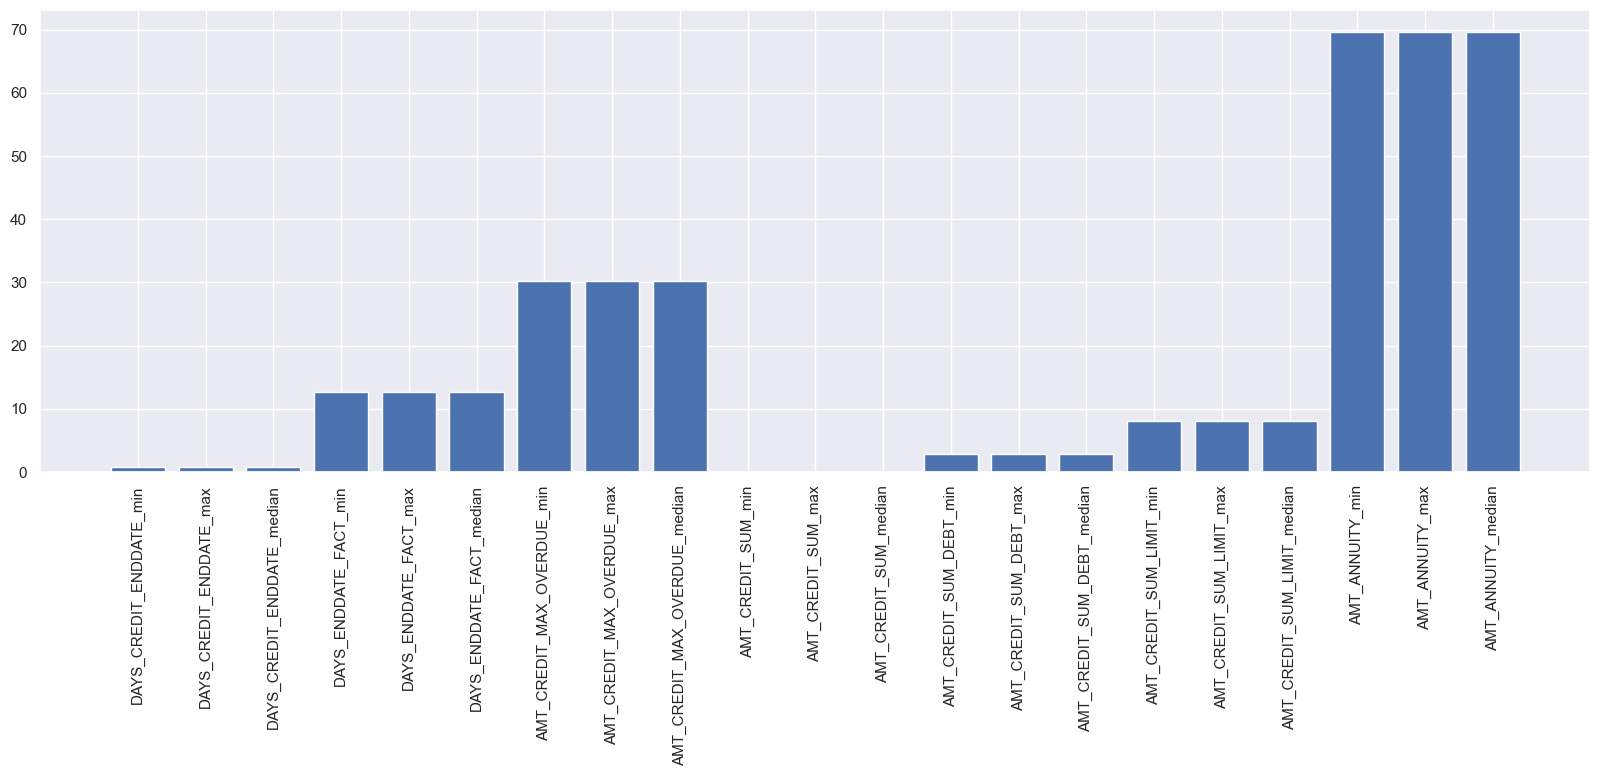

In [20]:
'''
all features having nulls with percentage of null values
'''
plot_data=bureau_agg_target.isnull().sum()*100/bureau_agg_target.shape[0]
plot_data=plot_data[plot_data>0]
ax=plt.axes()
ax.bar(plot_data.index, plot_data.values)
ax.tick_params(axis='x', rotation=90)
ax.get_figure().set_size_inches(20, 6)

### Functions

In [21]:
def plot_hist_box(data, feature):
    '''
    takes dataframe and a feature name, outputs a plot with boxplot and histogram of the feature
    '''
    fig, axes=plt.subplots(ncols=2)
    fig.set_size_inches(w=10, h=5)
    axes[0].boxplot(data[feature].dropna());
    axes[0].set_xticklabels([feature]);
    axes[1].hist(data[feature]);
    return axes

In [22]:
def plot_hist_default_pct(feature, dataframe, bins):
    '''
    takes a dataframe, a feature name and number of bins. Plots a histogram of the feature such that binning is equal width, and the value is the deafult percentage of that bin.  
    '''
    df=dataframe.copy()
    df['%s_binned'%feature]=pd.qcut(df[feature], q=bins, precision=3, duplicates='drop')
    counts=df['%s_binned'%feature].value_counts()
    default_counts=df.loc[df['TARGET']==1, '%s_binned'%feature].value_counts()
    default_counts=default_counts*100/counts
    default_counts.sort_index(inplace=True)
    ax=plt.axes()
    ax.bar(default_counts.index.astype(str), default_counts.values)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title('Deafulters %% in %s'%feature)
    ax.set_xlabel('Category')
    ax.set_ylabel('Defaulter %')
    print(default_counts)


In [23]:
def calc_iqr(feature, data):
    '''
    takes a dataframe and a feature name, returns the the 1st quartile, 3rd quartile and the inter-quartile range
    '''
    q3=data[feature].quantile(0.75)
    q1=data[feature].quantile(0.25)
    iqr=q3-q1
    return q1, q3, iqr

In [24]:
def plot_kde_vs_target(feature, main_data):
    '''
    takes a dataframe and a feature name, plots two kernel density plots, one for deafulter customers and other of non-deafulter customers. plots nothing of the variance of the feature is zero. 
    '''
    paid=main_data[main_data['TARGET']==0][feature]
    defaulted=main_data[main_data['TARGET']==1][feature]
    sns.kdeplot(paid, label='Paid', color='b')
    sns.kdeplot(defaulted, label='Defaulted', color='r')
    plt.legend()

In [25]:
def plot_all_numeric_kde(main_data, numerical_features):
    '''
    takes a dataframe and an index of feature names, plots the kernel density plots of all features present in numerical_features   
    '''
    fig, axes=plt.subplots(numerical_features.shape[0])
    fig.set_size_inches(10, 4*numerical_features.shape[0])
    for i, feature in enumerate(numerical_features):
        q1, q3, iqr=calc_iqr(feature, main_data)
        plot_data=main_data.loc[(main_data[feature]>=q1-1.5*iqr) & (main_data[feature]<=q3+1.5*iqr), :]
        paid=plot_data[plot_data['TARGET']==0][feature]
        defaulted=plot_data[plot_data['TARGET']==1][feature]
        sns.kdeplot(paid, label='Paid', color='b', ax=axes[i])
        sns.kdeplot(defaulted, label='Defaulted', color='r', ax=axes[i])
        axes[i].legend()

In [26]:
def plot_pie_target(target_series, ax=None):
    if ax is None:
        ax=plt.axes()
    plot_data=target_series.value_counts()
    plot_data.rename(index={0: "Paid", 1: "Defaulted"}, inplace=True)
    ax.pie(x=plot_data.values, labels=plot_data.index, autopct='%1.1f%%')
    return ax



In [27]:
def median_vs_target(feature, data):
    '''
    takes a feature name and a dataframe. prints two values, one is median of non-defaulters while other is median of deafulters
    '''
    print('Median of %s with target=0 : %f'%(feature, data.loc[data['TARGET']==0, feature].median()))
    print('Median of %s with target=1 : %f'%(feature, data.loc[data['TARGET']==1, feature].median()))

In [28]:
# plot_all_numeric_kde(bureau_agg_target, bureau_agg_target.columns)

In [29]:
del bureau
del bureau_agg
del bureau_balance_agg
gc.collect()

76

In [30]:
'''
numerical_features and numerical frame now consists of aggregated bureau data, previously contained raw burea data
'''
numerical_features=pd.Index(['DAYS_CREDIT_min', 'DAYS_CREDIT_max', 'DAYS_CREDIT_median',
                             'DAYS_CREDIT_ENDDATE_min', 'DAYS_CREDIT_ENDDATE_max', 'DAYS_CREDIT_ENDDATE_median',
                             'DAYS_ENDDATE_FACT_min', 'DAYS_ENDDATE_FACT_median', 'DAYS_CREDIT_UPDATE_min',
                             'STATUS_NO_DPD_max', 'STATUS_<31DPD_max', 'STATUS_<61DPD_max', 'STATUS_<91DPD_max', 
                             'STATUS_<121DPD_max', 'STATUS_CLOSED_max', 'STATUS_NA_max', 'STATUS_TOTAL_max', 
                             'DAYS_CREDIT_UPDATE_median', 'SK_ID_CURR', 'TARGET'])
numerical_frame=bureau_agg_target[numerical_features].copy()

### DAYS_CREDIT_min oldest application

In [31]:
numerical_frame['DAYS_CREDIT_min'].isnull().sum()

0

In [32]:
numerical_frame['DAYS_CREDIT_min'].describe()

count    263491.000000
mean      -1762.374882
std         863.862181
min       -2922.000000
25%       -2583.000000
50%       -1827.000000
75%       -1035.000000
max           0.000000
Name: DAYS_CREDIT_min, dtype: float64

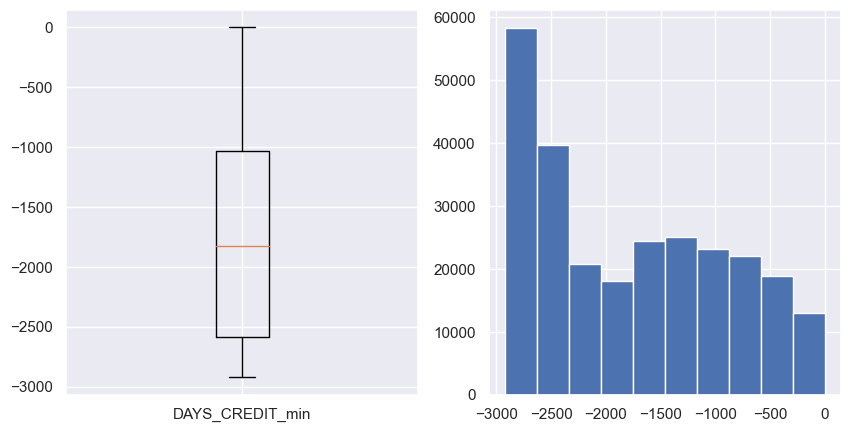

In [33]:
plot_hist_box(numerical_frame, 'DAYS_CREDIT_min');

Median of DAYS_CREDIT_min with target=0 : -1861.000000
Median of DAYS_CREDIT_min with target=1 : -1469.000000


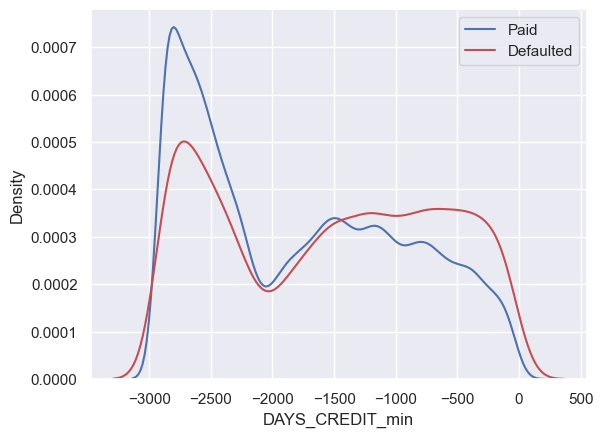

In [34]:
plot_kde_vs_target('DAYS_CREDIT_min', numerical_frame)
median_vs_target('DAYS_CREDIT_min', numerical_frame)

Median of YEARS_CREDIT_min with target=0 : 5.098630
Median of YEARS_CREDIT_min with target=1 : 4.024658


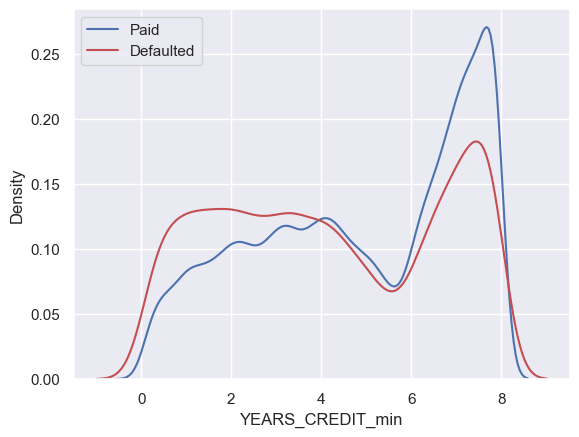

In [35]:
numerical_frame['YEARS_CREDIT_min']=numerical_frame['DAYS_CREDIT_min']/-365
plot_kde_vs_target('YEARS_CREDIT_min', numerical_frame)
median_vs_target('YEARS_CREDIT_min', numerical_frame)

(-0.001, 1.493]    12.368565
(1.493, 2.57]       9.703375
(2.57, 3.542]       8.628765
(3.542, 4.463]      7.755325
(4.463, 5.712]      6.977301
(5.712, 6.655]      6.442052
(6.655, 7.2]        6.044332
(7.2, 7.652]        5.932232
(7.652, 8.005]      5.708911
Name: YEARS_CREDIT_min_binned, dtype: float64


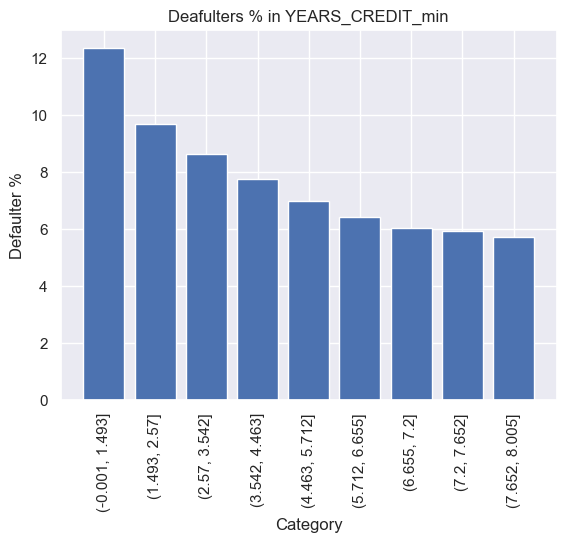

In [36]:
plot_hist_default_pct('YEARS_CREDIT_min', numerical_frame, 9)

### DAYS_CREDIT_max newest application

In [37]:
numerical_frame['DAYS_CREDIT_max'].isnull().sum()

0

In [38]:
numerical_frame['DAYS_CREDIT_max'].describe()

count    263491.000000
mean       -489.297817
std         537.574145
min       -2922.000000
25%        -620.000000
50%        -300.000000
75%        -143.000000
max           0.000000
Name: DAYS_CREDIT_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

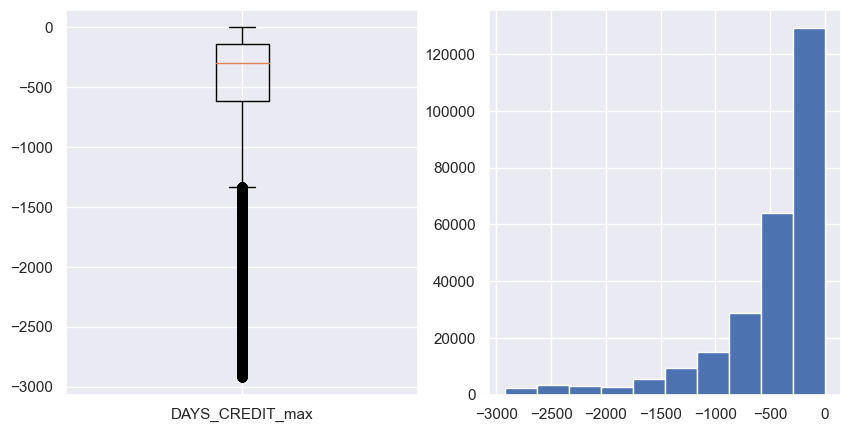

In [39]:
plot_hist_box(numerical_frame, 'DAYS_CREDIT_max')

Median of DAYS_CREDIT_max with target=0 : -308.000000
Median of DAYS_CREDIT_max with target=1 : -221.000000


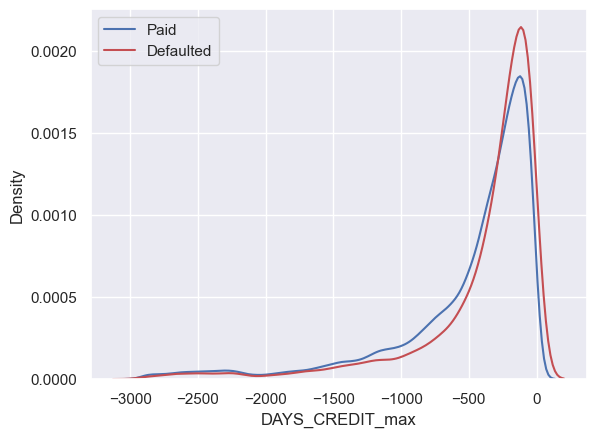

In [40]:
plot_kde_vs_target('DAYS_CREDIT_max', numerical_frame)
median_vs_target('DAYS_CREDIT_max', numerical_frame)

Median of YEARS_CREDIT_max with target=0 : 0.843836
Median of YEARS_CREDIT_max with target=1 : 0.605479


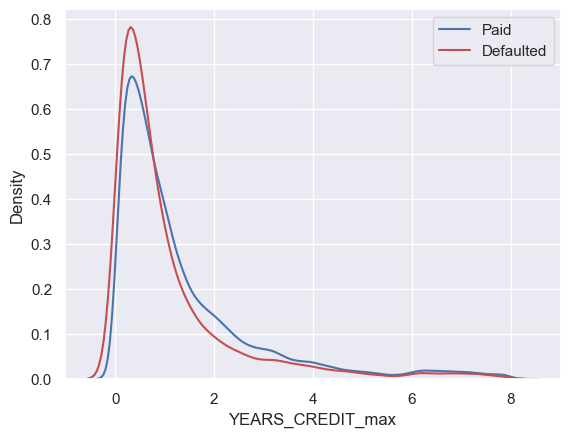

In [41]:
'''
converts days to years scale for better understanding
'''
numerical_frame['YEARS_CREDIT_max']=numerical_frame['DAYS_CREDIT_max']/-365
plot_kde_vs_target('YEARS_CREDIT_max', numerical_frame)
median_vs_target('YEARS_CREDIT_max', numerical_frame)

(-0.001, 0.2]     12.237372
(0.2, 0.351]       9.380792
(0.351, 0.518]     8.784495
(0.518, 0.71]      8.470588
(0.71, 0.953]      7.186455
(0.953, 1.29]      6.350838
(1.29, 1.879]      5.983227
(1.879, 3.033]     5.171825
(3.033, 8.005]     5.952218
Name: YEARS_CREDIT_max_binned, dtype: float64


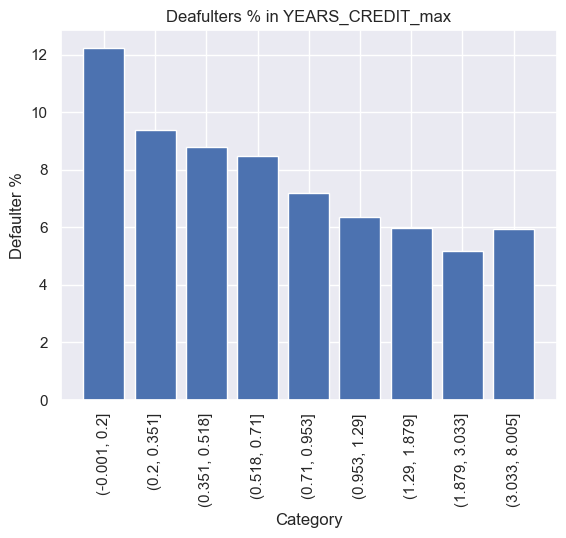

In [42]:
plot_hist_default_pct('YEARS_CREDIT_max', numerical_frame, 9)

### DAYS_CREDIT_median (mi, more variability in graph)

In [43]:
numerical_frame['DAYS_CREDIT_median'].isnull().sum()

0

In [44]:
numerical_frame['DAYS_CREDIT_median'].describe()

count    263491.000000
mean      -1049.644056
std         625.841540
min       -2922.000000
25%       -1418.000000
50%        -958.000000
75%        -567.500000
max           0.000000
Name: DAYS_CREDIT_median, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

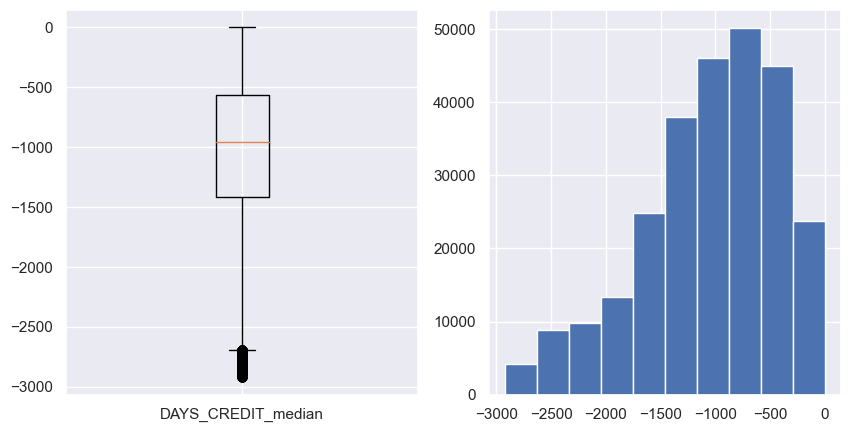

In [45]:
plot_hist_box(numerical_frame, 'DAYS_CREDIT_median')

Median of DAYS_CREDIT_median with target=0 : -976.000000
Median of DAYS_CREDIT_median with target=1 : -729.000000


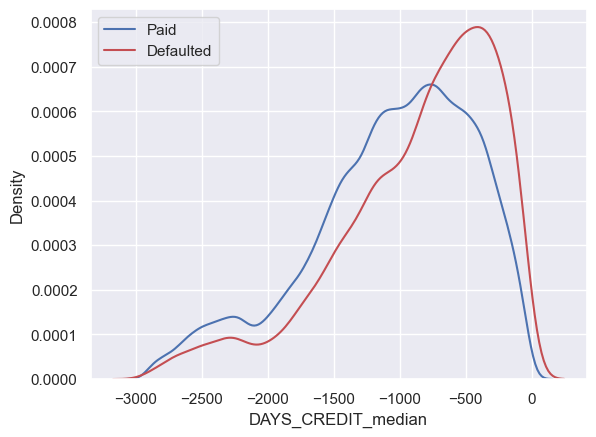

In [46]:
plot_kde_vs_target('DAYS_CREDIT_median', numerical_frame)
median_vs_target('DAYS_CREDIT_median', numerical_frame)

Median of YEARS_CREDIT_median with target=0 : 2.673973
Median of YEARS_CREDIT_median with target=1 : 1.997260


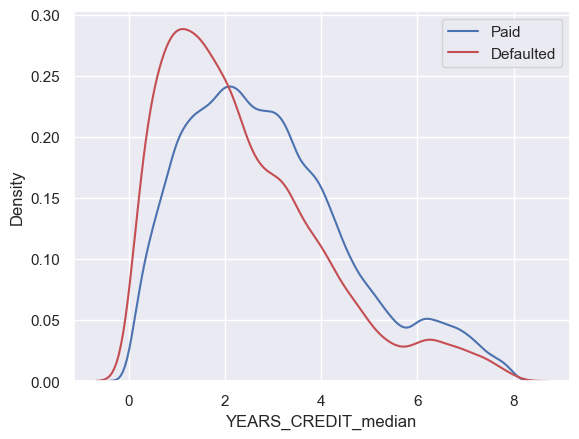

In [47]:
numerical_frame['YEARS_CREDIT_median']=numerical_frame['DAYS_CREDIT_median']/-365
plot_kde_vs_target('YEARS_CREDIT_median', numerical_frame)
median_vs_target('YEARS_CREDIT_median', numerical_frame)

(-0.001, 0.918]    13.843482
(0.918, 1.43]      10.354513
(1.43, 1.915]       9.083779
(1.915, 2.375]      7.690996
(2.375, 2.879]      6.259187
(2.879, 3.404]      6.102692
(3.404, 4.06]       5.736196
(4.06, 5.142]       5.362344
(5.142, 8.005]      5.117169
Name: YEARS_CREDIT_median_binned, dtype: float64


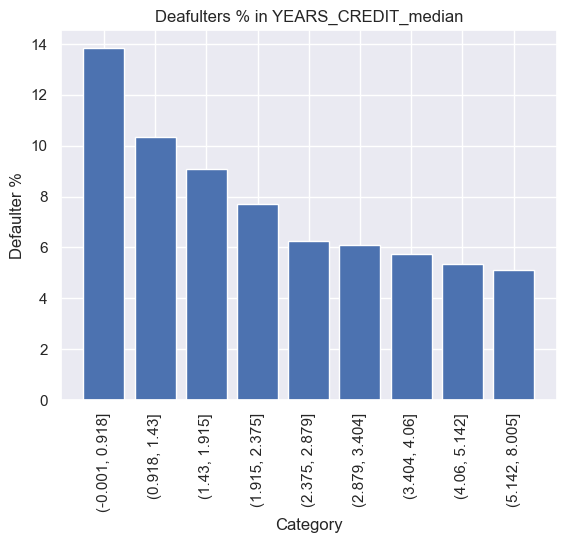

In [48]:
plot_hist_default_pct('YEARS_CREDIT_median', numerical_frame, 9)

### DAYS_CREDIT_ENDDATE_min (mi, less outliers and more uniform trend)
if finished(negative) then oldest loan. If left(positive), then loan that the nearest deadline

In [49]:
numerical_frame['DAYS_CREDIT_ENDDATE_min'].isnull().sum()

2249

In [50]:
numerical_frame['DAYS_CREDIT_ENDDATE_min'].describe()

count    261242.000000
mean      -1029.578131
std        2640.338801
min      -42060.000000
25%       -2132.000000
50%       -1268.000000
75%        -449.000000
max       31198.000000
Name: DAYS_CREDIT_ENDDATE_min, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

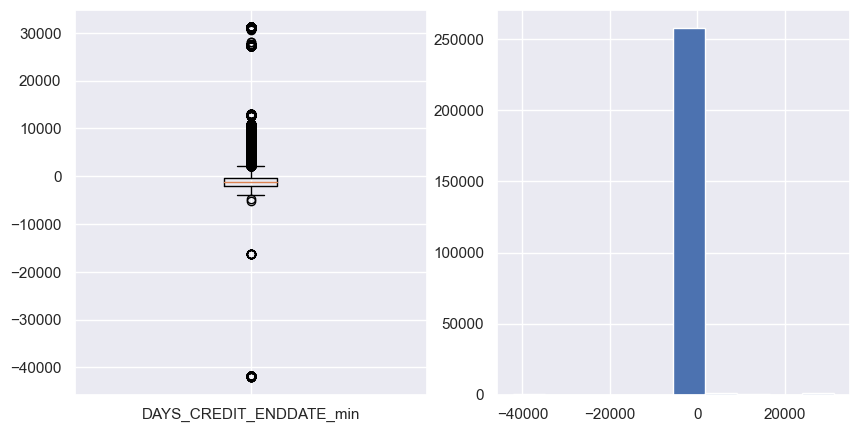

In [51]:
plot_hist_box(numerical_frame, 'DAYS_CREDIT_ENDDATE_min')

Number of outliers : 1954


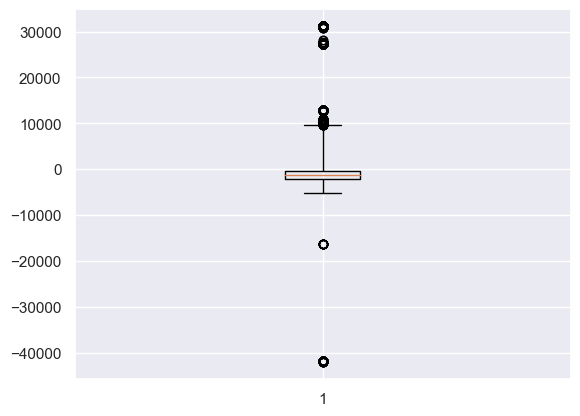

In [52]:
'''
this cell adjusts the outlier range, marks outlier records (nans remain unchanged), and also scales the data to year scale.
'''
plt.boxplot(numerical_frame['DAYS_CREDIT_ENDDATE_min'].dropna(), whis=6);
numerical_frame['YEARS_CREDIT_ENDDATE_min']=numerical_frame['DAYS_CREDIT_ENDDATE_min']/365
q1, q3, iqr=calc_iqr('DAYS_CREDIT_ENDDATE_min', numerical_frame)
numerical_frame['DAYS_CREDIT_ENDDATE_min_outlier']=0
numerical_frame.loc[(numerical_frame['DAYS_CREDIT_ENDDATE_min']<q1-6*iqr) | 
                    (numerical_frame['DAYS_CREDIT_ENDDATE_min']>q3+6*iqr), 'DAYS_CREDIT_ENDDATE_min_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['DAYS_CREDIT_ENDDATE_min_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['DAYS_CREDIT_ENDDATE_min_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

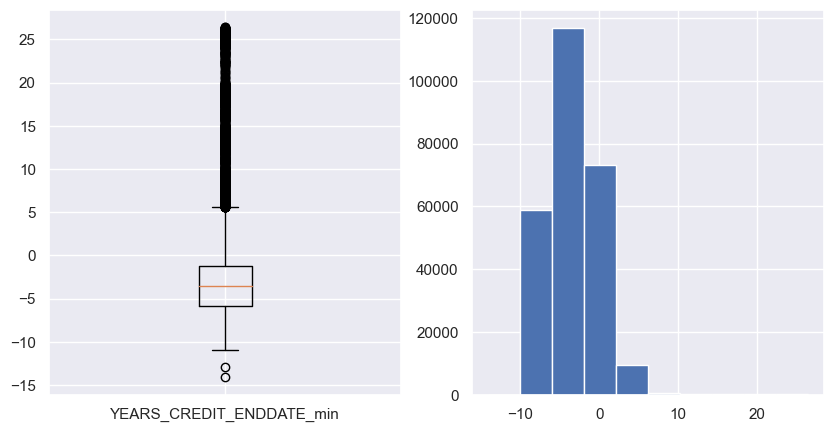

In [53]:
plot_hist_box(good_frame, 'YEARS_CREDIT_ENDDATE_min')

Median of YEARS_CREDIT_ENDDATE_min with target=0 : -3.569863
Median of YEARS_CREDIT_ENDDATE_min with target=1 : -2.668493


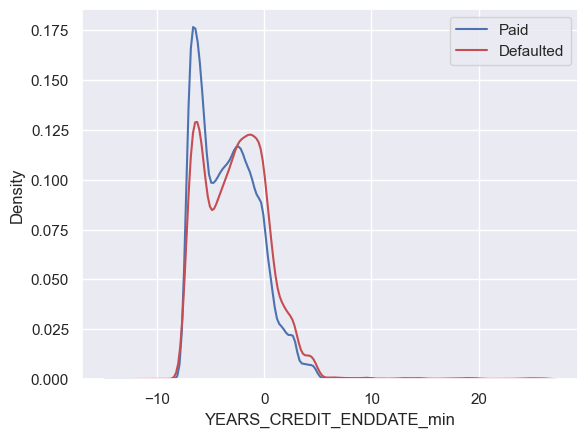

In [54]:
plot_kde_vs_target('YEARS_CREDIT_ENDDATE_min', good_frame)
median_vs_target('YEARS_CREDIT_ENDDATE_min', good_frame)

(-14.110999999999999, -6.679]     5.653306
(-6.679, -6.03]                   6.064176
(-6.03, -5.164]                   6.296862
(-5.164, -4.027]                  6.748743
(-4.027, -2.989]                  7.201889
(-2.989, -2.041]                  7.822881
(-2.041, -1.008]                  8.694898
(-1.008, 0.228]                  10.020151
(0.228, 26.422]                  10.586602
Name: YEARS_CREDIT_ENDDATE_min_binned, dtype: float64


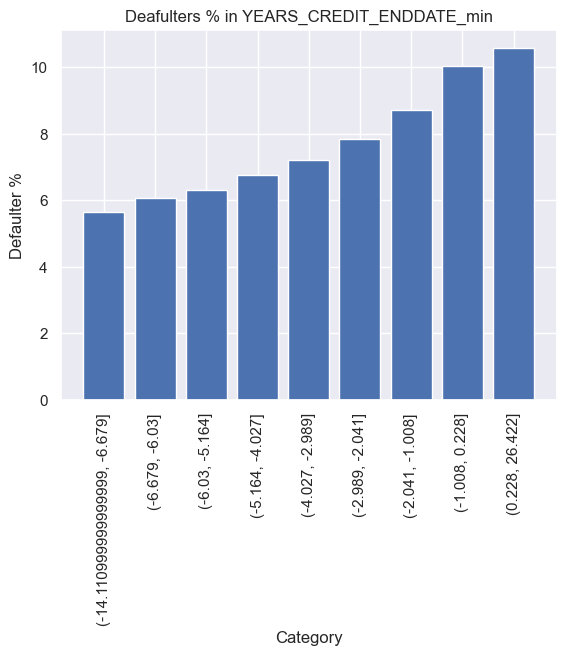

In [55]:
plot_hist_default_pct('YEARS_CREDIT_ENDDATE_min', good_frame, 9)

### DAYS_CREDIT_ENDDATE_max
if loan is finished(negative) then the recent most finished loan, if not finished(positive) then the loan which has farthest deadline

In [56]:
numerical_frame['DAYS_CREDIT_ENDDATE_max'].isnull().sum()

2249

In [57]:
numerical_frame['DAYS_CREDIT_ENDDATE_max'].describe()

count    261242.000000
mean       4433.041953
std        9350.942497
min      -41875.000000
25%         125.000000
50%         909.000000
75%        1683.000000
max       31199.000000
Name: DAYS_CREDIT_ENDDATE_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

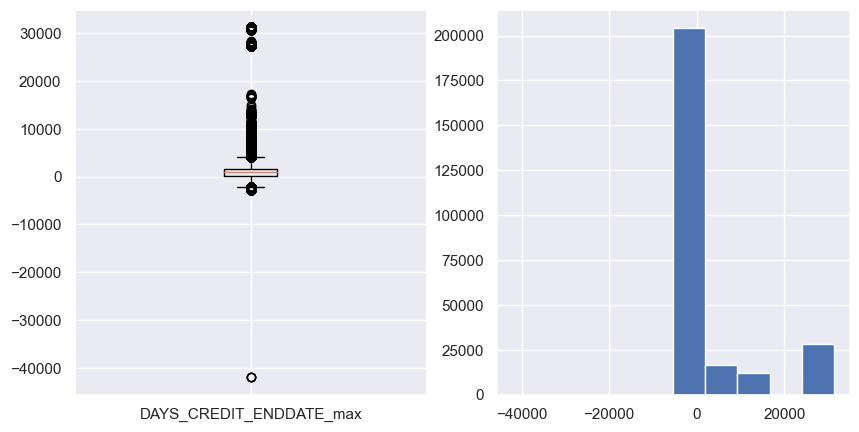

In [58]:
plot_hist_box(numerical_frame, 'DAYS_CREDIT_ENDDATE_max')

Number of outliers : 30571


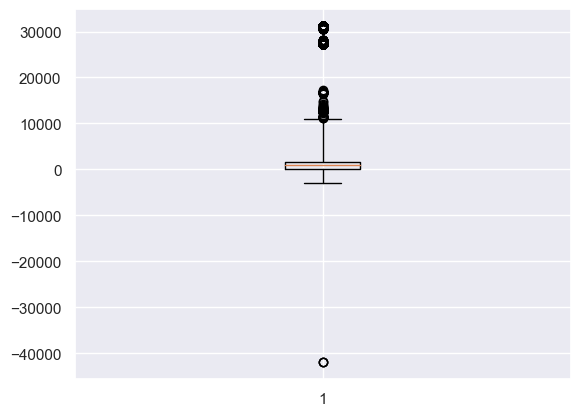

In [59]:
plt.boxplot(numerical_frame['DAYS_CREDIT_ENDDATE_max'].dropna(), whis=6);
numerical_frame['YEARS_CREDIT_ENDDATE_max']=numerical_frame['DAYS_CREDIT_ENDDATE_max']/365
q1, q3, iqr=calc_iqr('DAYS_CREDIT_ENDDATE_max', numerical_frame)
numerical_frame['DAYS_CREDIT_ENDDATE_max_outlier']=0
numerical_frame.loc[(numerical_frame['DAYS_CREDIT_ENDDATE_max']<q1-6*iqr) | 
                    (numerical_frame['DAYS_CREDIT_ENDDATE_max']>q3+6*iqr), 'DAYS_CREDIT_ENDDATE_max_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['DAYS_CREDIT_ENDDATE_max_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['DAYS_CREDIT_ENDDATE_max_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

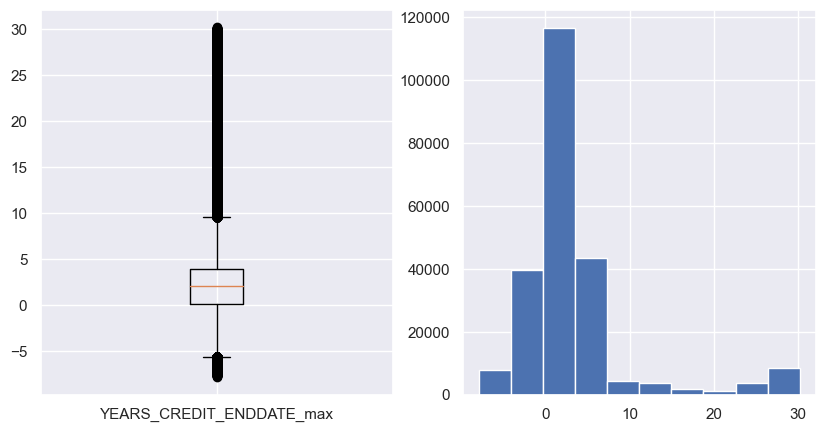

In [60]:
plot_hist_box(good_frame, 'YEARS_CREDIT_ENDDATE_max')

Median of YEARS_CREDIT_ENDDATE_max with target=0 : 1.989041
Median of YEARS_CREDIT_ENDDATE_max with target=1 : 2.438356


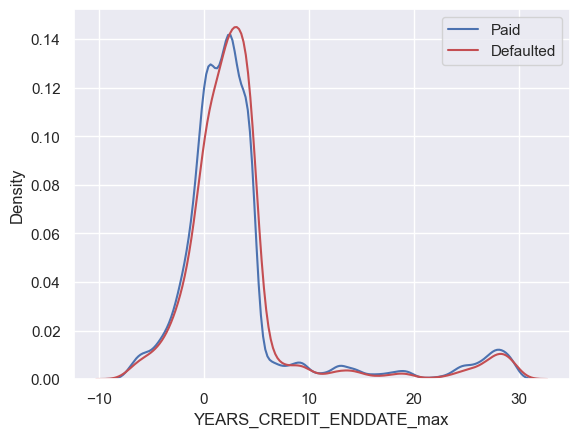

In [61]:
plot_kde_vs_target('YEARS_CREDIT_ENDDATE_max', good_frame)
median_vs_target('YEARS_CREDIT_ENDDATE_max', good_frame)

(-7.831, -1.523]      6.360162
(-1.523, -0.0986]     5.807283
(-0.0986, 0.696]      6.628567
(0.696, 1.622]        6.939015
(1.622, 2.425]        7.127825
(2.425, 3.107]        8.106523
(3.107, 4.104]        8.499201
(4.104, 5.926]       10.190435
(5.926, 30.178]       6.462691
Name: YEARS_CREDIT_ENDDATE_max_binned, dtype: float64


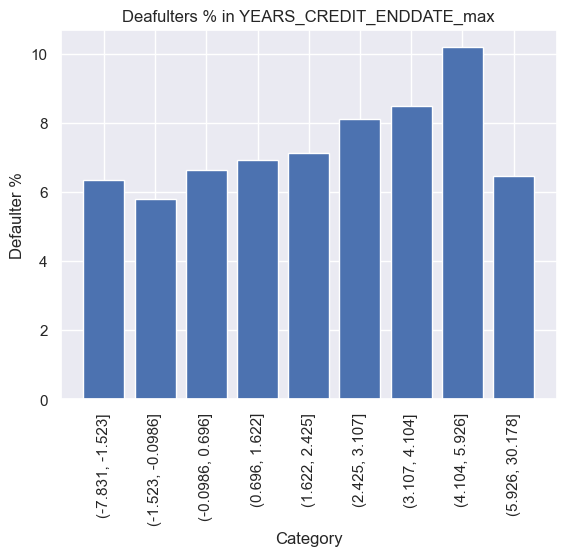

In [62]:
plot_hist_default_pct('YEARS_CREDIT_ENDDATE_max', good_frame, 9)

### DAYS_CREDIT_ENDDATE_median

In [63]:
numerical_frame['DAYS_CREDIT_ENDDATE_median'].isnull().sum()

2249

In [64]:
numerical_frame['DAYS_CREDIT_ENDDATE_median'].describe()

count    261242.000000
mean         83.644255
std        2925.374488
min      -41875.000000
25%        -819.000000
50%        -270.000000
75%         241.000000
max       31198.000000
Name: DAYS_CREDIT_ENDDATE_median, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

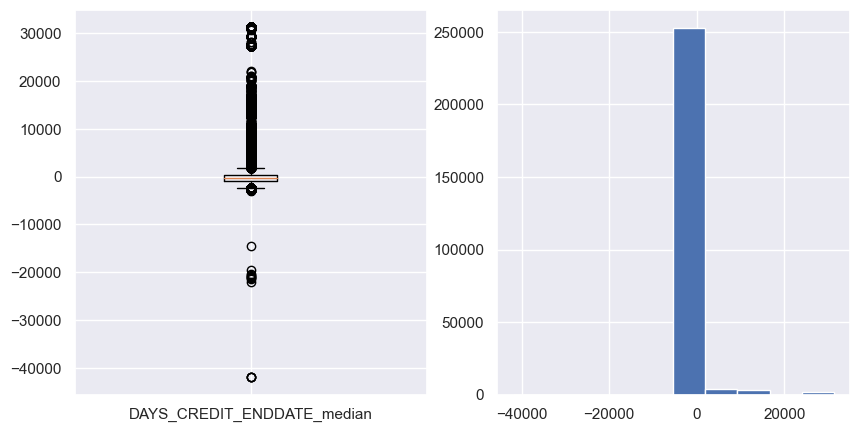

In [65]:
plot_hist_box(numerical_frame, 'DAYS_CREDIT_ENDDATE_median')

Number of outliers : 4118


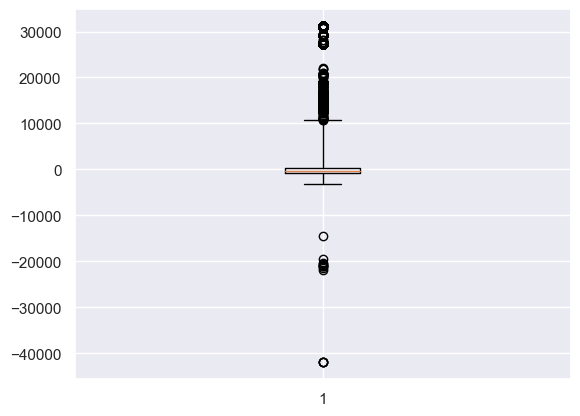

In [66]:
plt.boxplot(numerical_frame['DAYS_CREDIT_ENDDATE_median'].dropna(), whis=10);
numerical_frame['YEARS_CREDIT_ENDDATE_median']=numerical_frame['DAYS_CREDIT_ENDDATE_median']/365
q1, q3, iqr=calc_iqr('DAYS_CREDIT_ENDDATE_median', numerical_frame)
numerical_frame['DAYS_CREDIT_ENDDATE_median_outlier']=0
numerical_frame.loc[(numerical_frame['DAYS_CREDIT_ENDDATE_median']<q1-10*iqr) | 
                    (numerical_frame['DAYS_CREDIT_ENDDATE_median']>q3+10*iqr), 'DAYS_CREDIT_ENDDATE_median_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['DAYS_CREDIT_ENDDATE_median_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['DAYS_CREDIT_ENDDATE_median_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

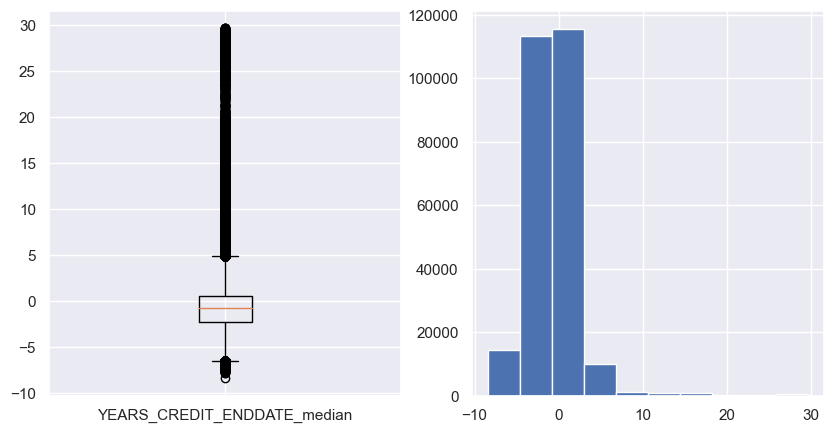

In [67]:
plot_hist_box(good_frame, 'YEARS_CREDIT_ENDDATE_median')

Median of YEARS_CREDIT_ENDDATE_median with target=0 : -0.830137
Median of YEARS_CREDIT_ENDDATE_median with target=1 : -0.194521


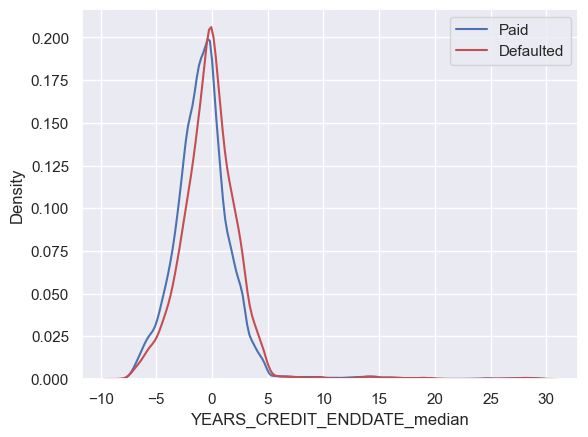

In [68]:
plot_kde_vs_target('YEARS_CREDIT_ENDDATE_median', good_frame)
median_vs_target('YEARS_CREDIT_ENDDATE_median', good_frame)

(-8.42, -3.607]      5.488274
(-3.607, -2.471]     5.490429
(-2.471, -1.718]     5.747489
(-1.718, -1.074]     6.274277
(-1.074, -0.485]     7.081470
(-0.485, 0.0411]     8.435088
(0.0411, 0.779]      9.061953
(0.779, 2.022]      10.450633
(2.022, 29.696]     10.555069
Name: YEARS_CREDIT_ENDDATE_median_binned, dtype: float64


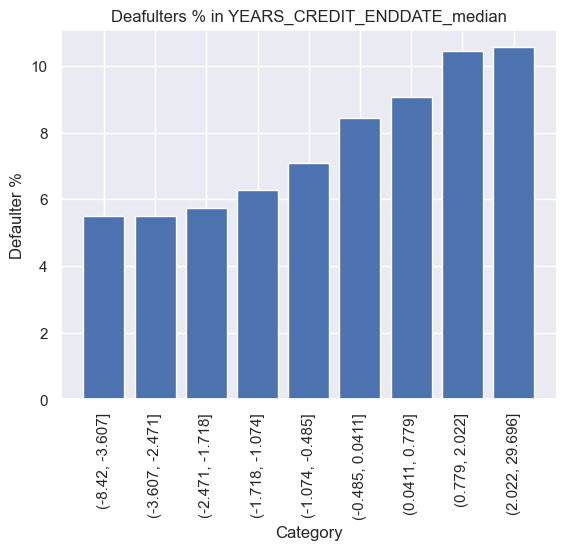

In [69]:
plot_hist_default_pct('YEARS_CREDIT_ENDDATE_median', good_frame, 9)

### DAYS_ENDDATE_FACT_min (mi, less outliers and more uniform trend)
oldest closed loan

In [70]:
numerical_frame['DAYS_ENDDATE_FACT_min'].isnull().sum()

33136

In [71]:
numerical_frame['DAYS_ENDDATE_FACT_min'].describe()

count    230355.000000
mean      -1467.338777
std         792.310701
min      -42023.000000
25%       -2211.000000
50%       -1452.000000
75%        -809.000000
max           0.000000
Name: DAYS_ENDDATE_FACT_min, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

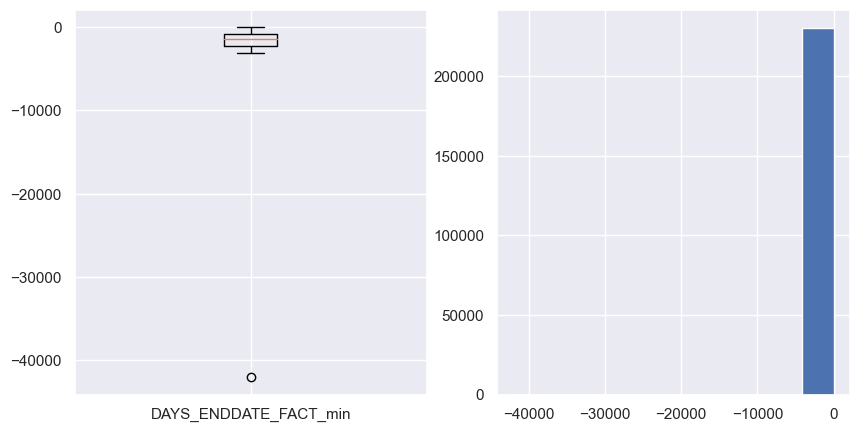

In [72]:
plot_hist_box(numerical_frame, 'DAYS_ENDDATE_FACT_min')

Number of outliers : 1


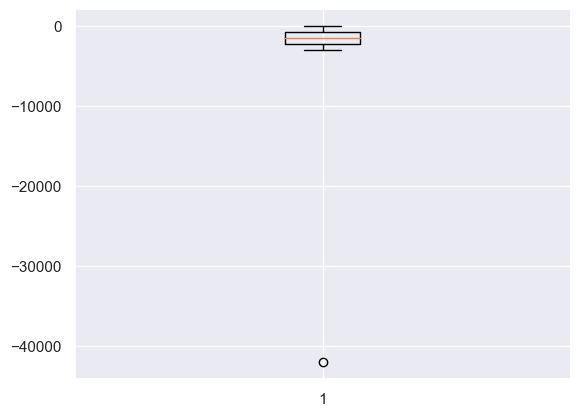

In [73]:
plt.boxplot(numerical_frame['DAYS_ENDDATE_FACT_min'].dropna(), whis=1.5);
numerical_frame['YEARS_ENDDATE_FACT_min']=numerical_frame['DAYS_ENDDATE_FACT_min']/-365
q1, q3, iqr=calc_iqr('DAYS_ENDDATE_FACT_min', numerical_frame)
numerical_frame['DAYS_ENDDATE_FACT_min_outlier']=0
numerical_frame.loc[(numerical_frame['DAYS_ENDDATE_FACT_min']<q1-1.5*iqr) | 
                    (numerical_frame['DAYS_ENDDATE_FACT_min']>q3+1.5*iqr), 'DAYS_ENDDATE_FACT_min_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['DAYS_ENDDATE_FACT_min_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['DAYS_ENDDATE_FACT_min_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

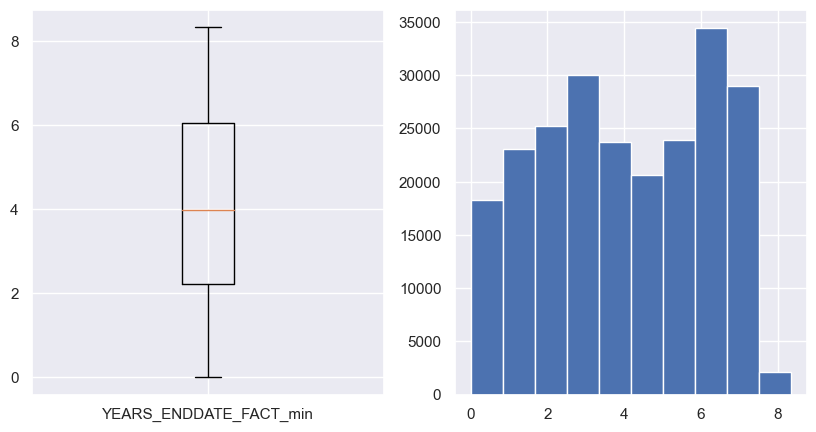

In [74]:
plot_hist_box(good_frame, 'YEARS_ENDDATE_FACT_min')

Median of YEARS_ENDDATE_FACT_min with target=0 : 4.030137
Median of YEARS_ENDDATE_FACT_min with target=1 : 3.290411


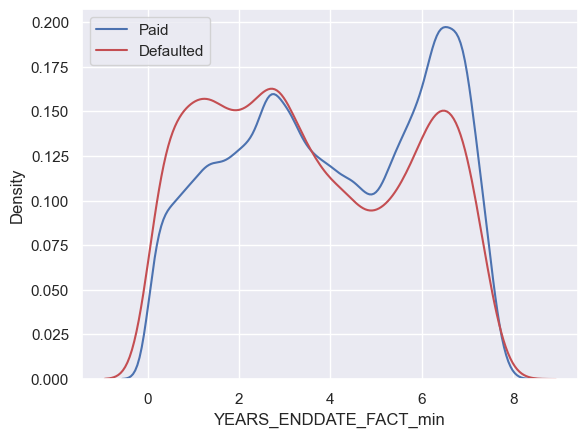

In [75]:
plot_kde_vs_target('YEARS_ENDDATE_FACT_min', good_frame)
median_vs_target('YEARS_ENDDATE_FACT_min', good_frame)

(-0.001, 1.112]    10.330288
(1.112, 2.008]      8.979910
(2.008, 2.77]       7.885991
(2.77, 3.526]       7.447931
(3.526, 4.46]       6.986558
(4.46, 5.485]       6.260734
(5.485, 6.222]      5.994540
(6.222, 6.792]      5.870872
(6.792, 8.334]      5.564063
Name: YEARS_ENDDATE_FACT_min_binned, dtype: float64


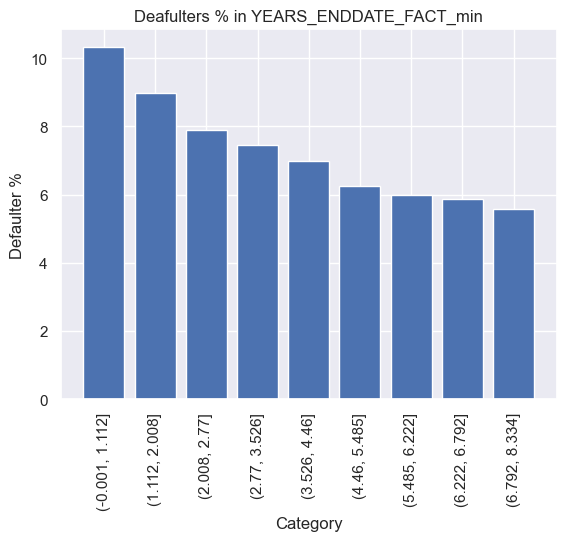

In [76]:
plot_hist_default_pct('YEARS_ENDDATE_FACT_min', good_frame, 9)

### DAYS_ENDDATE_FACT_median

In [77]:
numerical_frame['DAYS_ENDDATE_FACT_median'].isnull().sum()

33136

In [78]:
numerical_frame['DAYS_ENDDATE_FACT_median'].describe()

count    230355.000000
mean       -948.229550
std         576.058846
min       -2887.000000
25%       -1280.000000
50%        -873.500000
75%        -508.000000
max           0.000000
Name: DAYS_ENDDATE_FACT_median, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

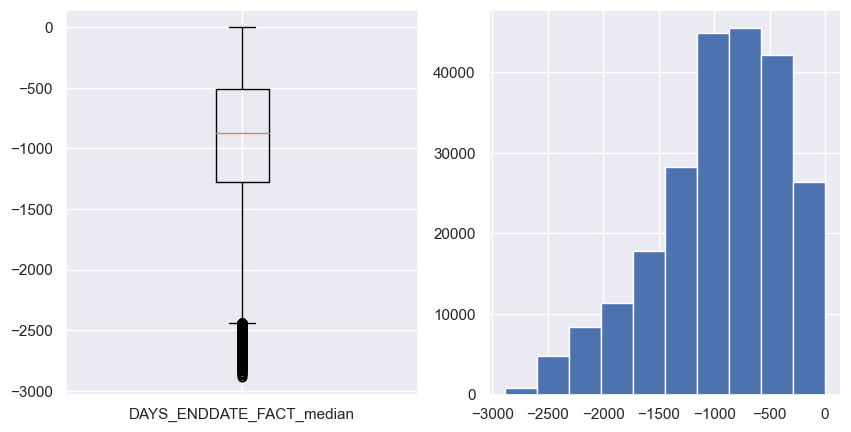

In [79]:
plot_hist_box(numerical_frame, 'DAYS_ENDDATE_FACT_median')

Median of YEARS_ENDDATE_FACT_median with target=0 : 2.419178
Median of YEARS_ENDDATE_FACT_median with target=1 : 2.054795


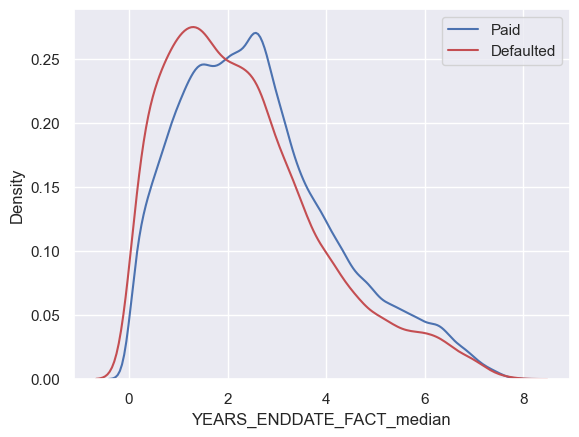

In [80]:
numerical_frame['YEARS_ENDDATE_FACT_median']=numerical_frame['DAYS_ENDDATE_FACT_median']/-365
plot_kde_vs_target('YEARS_ENDDATE_FACT_median', numerical_frame)
median_vs_target('YEARS_ENDDATE_FACT_median', numerical_frame)

(-0.001, 0.773]    10.528782
(0.773, 1.278]      8.826977
(1.278, 1.727]      8.166374
(1.727, 2.175]      7.170105
(2.175, 2.597]      6.631352
(2.597, 3.052]      6.141034
(3.052, 3.697]      6.410508
(3.697, 4.736]      5.828089
(4.736, 7.91]       5.622631
Name: YEARS_ENDDATE_FACT_median_binned, dtype: float64


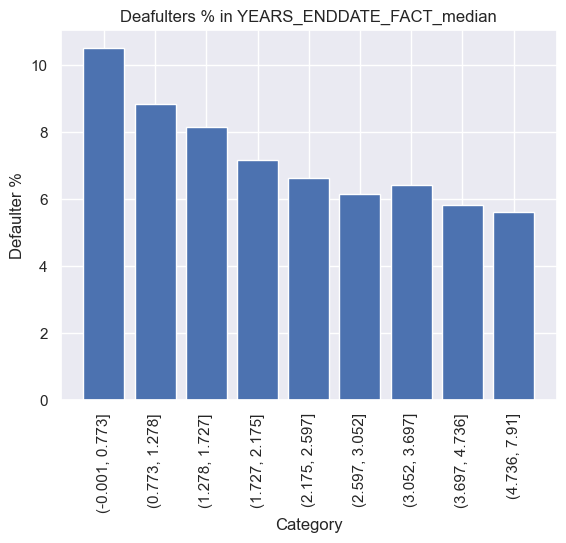

In [81]:
plot_hist_default_pct('YEARS_ENDDATE_FACT_median', numerical_frame, 9)

### DAYS_CREDIT_UPDATE_min (mi, less outliers and more difference in medians of the two classes)
oldest update

In [82]:
numerical_frame['DAYS_CREDIT_UPDATE_min'].isnull().sum()

0

In [83]:
numerical_frame['DAYS_CREDIT_UPDATE_min'].describe()

count    263491.000000
mean      -1181.361048
std        1118.149908
min      -41947.000000
25%       -1902.000000
50%       -1055.000000
75%        -474.000000
max          14.000000
Name: DAYS_CREDIT_UPDATE_min, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

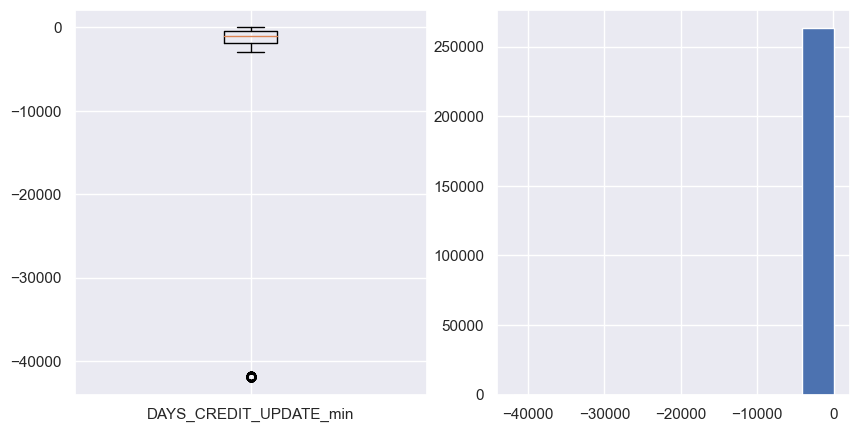

In [84]:
plot_hist_box(numerical_frame, 'DAYS_CREDIT_UPDATE_min')

Number of outliers : 90


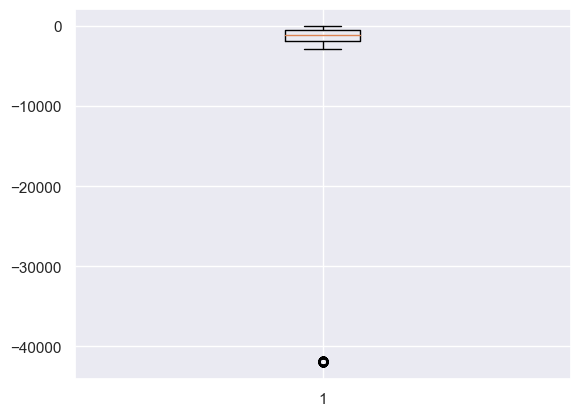

In [85]:
plt.boxplot(numerical_frame['DAYS_CREDIT_UPDATE_min'].dropna(), whis=1.5);
numerical_frame['YEARS_CREDIT_UPDATE_min']=numerical_frame['DAYS_CREDIT_UPDATE_min']/-365
q1, q3, iqr=calc_iqr('DAYS_CREDIT_UPDATE_min', numerical_frame)
numerical_frame['DAYS_CREDIT_UPDATE_min_outlier']=0
numerical_frame.loc[(numerical_frame['DAYS_CREDIT_UPDATE_min']<q1-1.5*iqr) | 
                    (numerical_frame['DAYS_CREDIT_UPDATE_min']>q3+1.5*iqr), 'DAYS_CREDIT_UPDATE_min_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['DAYS_CREDIT_UPDATE_min_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['DAYS_CREDIT_UPDATE_min_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

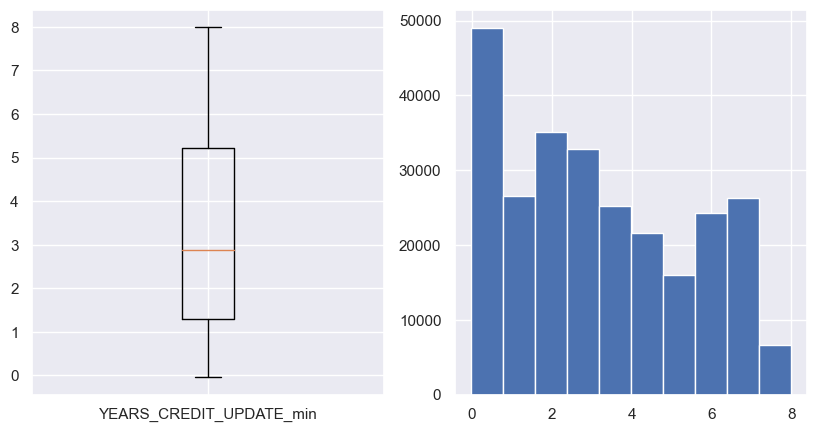

In [86]:
plot_hist_box(good_frame, 'YEARS_CREDIT_UPDATE_min')

Median of YEARS_CREDIT_UPDATE_min with target=0 : 2.939726
Median of YEARS_CREDIT_UPDATE_min with target=1 : 2.284932


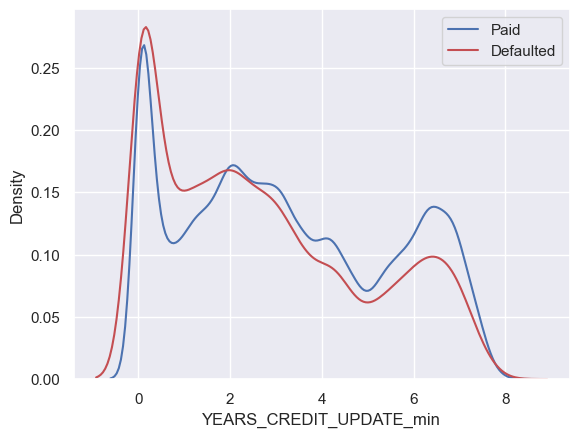

In [87]:
plot_kde_vs_target('YEARS_CREDIT_UPDATE_min', good_frame)
median_vs_target('YEARS_CREDIT_UPDATE_min', good_frame)

(-0.0394, 0.178]    11.272690
(0.178, 1.088]       9.816391
(1.088, 1.882]       8.762165
(1.882, 2.534]       7.621555
(2.534, 3.244]       7.309242
(3.244, 4.203]       6.666439
(4.203, 5.526]       6.421611
(5.526, 6.482]       6.082717
(6.482, 7.992]       5.581252
Name: YEARS_CREDIT_UPDATE_min_binned, dtype: float64


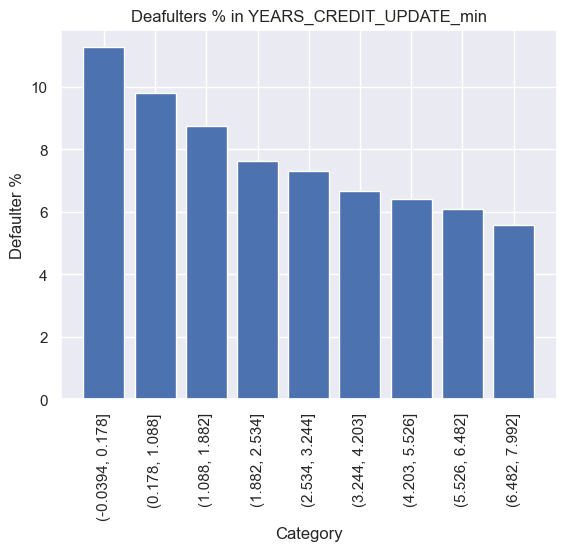

In [88]:
plot_hist_default_pct('YEARS_CREDIT_UPDATE_min', good_frame, 9)

### DAYS_CREDIT_UPDATE_median

In [89]:
numerical_frame['DAYS_CREDIT_UPDATE_median'].isnull().sum()

0

In [90]:
numerical_frame['DAYS_CREDIT_UPDATE_median'].describe()

count    263491.000000
mean       -469.217804
std         475.327319
min      -41890.000000
25%        -713.500000
50%        -361.000000
75%         -71.000000
max          14.000000
Name: DAYS_CREDIT_UPDATE_median, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

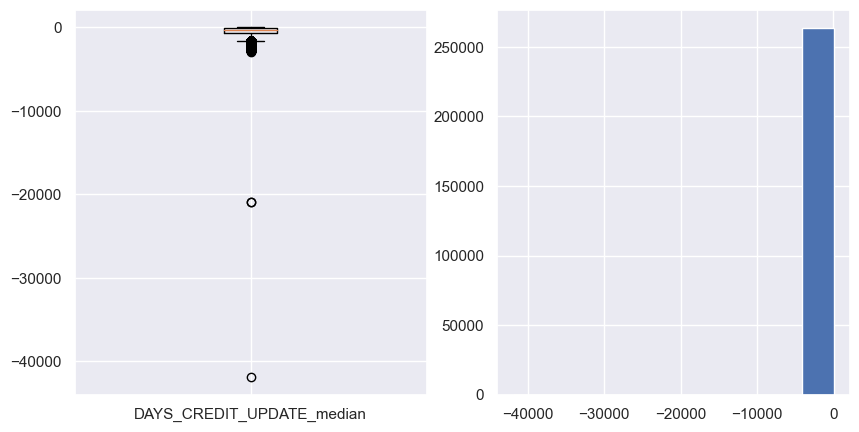

In [91]:
plot_hist_box(numerical_frame, 'DAYS_CREDIT_UPDATE_median')

Number of outliers : 7198


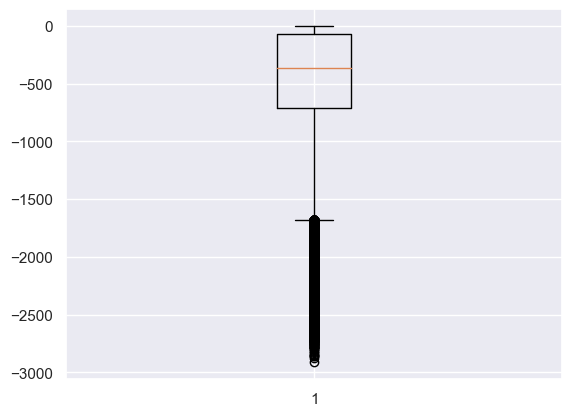

In [92]:
plt.boxplot(numerical_frame.loc[numerical_frame['DAYS_CREDIT_UPDATE_median'].between(-20000, 0), 'DAYS_CREDIT_UPDATE_median'], whis=1.5);
numerical_frame['YEARS_CREDIT_UPDATE_median']=numerical_frame['DAYS_CREDIT_UPDATE_median']/-365
q1, q3, iqr=calc_iqr('DAYS_CREDIT_UPDATE_median', numerical_frame)
numerical_frame['DAYS_CREDIT_UPDATE_median_outlier']=0
numerical_frame.loc[(numerical_frame['DAYS_CREDIT_UPDATE_median']<q1-1.5*iqr) | 
                    (numerical_frame['DAYS_CREDIT_UPDATE_median']>q3+1.5*iqr), 'DAYS_CREDIT_UPDATE_median_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['DAYS_CREDIT_UPDATE_median_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['DAYS_CREDIT_UPDATE_median_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

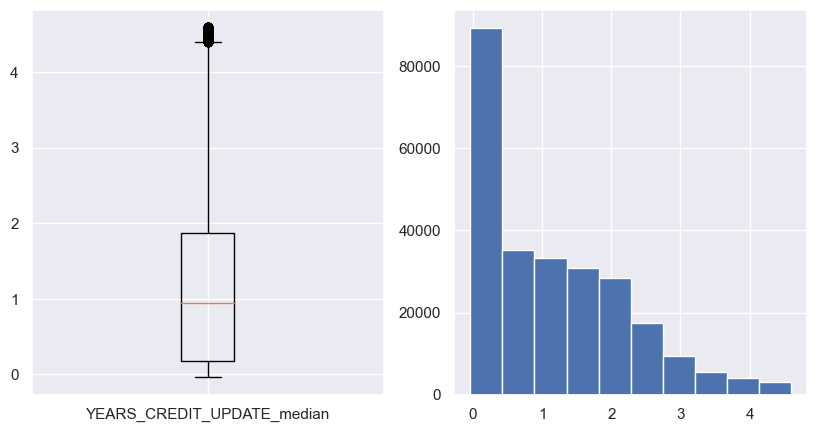

In [93]:
plot_hist_box(good_frame, 'YEARS_CREDIT_UPDATE_median')

Median of YEARS_CREDIT_UPDATE_median with target=0 : 0.976712
Median of YEARS_CREDIT_UPDATE_median with target=1 : 0.512329


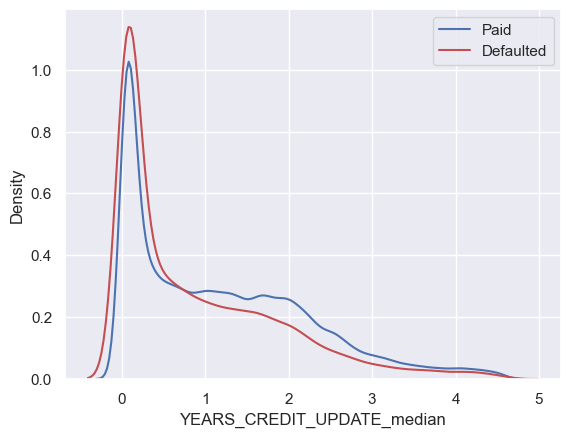

In [94]:
plot_kde_vs_target('YEARS_CREDIT_UPDATE_median', good_frame)
median_vs_target('YEARS_CREDIT_UPDATE_median', good_frame)

(-0.0394, 0.063]    12.104902
(0.063, 0.14]       11.065545
(0.14, 0.381]        8.761319
(0.381, 0.738]       8.008156
(0.738, 1.135]       7.250044
(1.135, 1.553]       6.558239
(1.553, 1.978]       5.965480
(1.978, 2.542]       5.235970
(2.542, 4.595]       5.232660
Name: YEARS_CREDIT_UPDATE_median_binned, dtype: float64


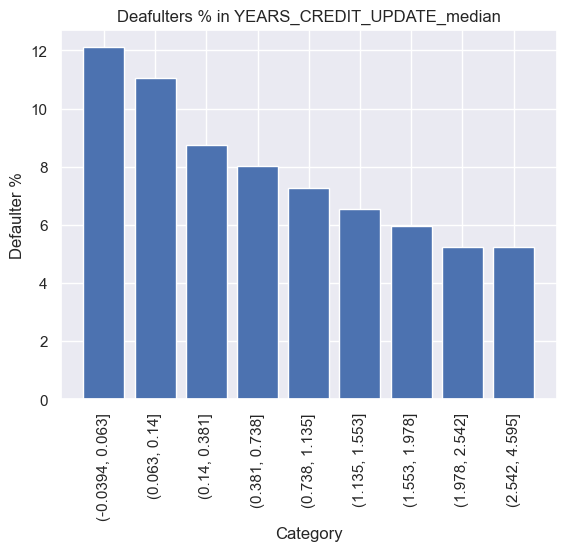

In [95]:
plot_hist_default_pct('YEARS_CREDIT_UPDATE_median', good_frame, 9)

### STATUS_NO_DPD_max

In [96]:
numerical_frame['STATUS_NO_DPD_max'].isnull().sum()

0

In [97]:
numerical_frame['STATUS_NO_DPD_max'].describe()

count    263491.000000
mean          5.597193
std          10.974887
min           0.000000
25%           0.000000
50%           0.000000
75%           8.000000
max          95.000000
Name: STATUS_NO_DPD_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

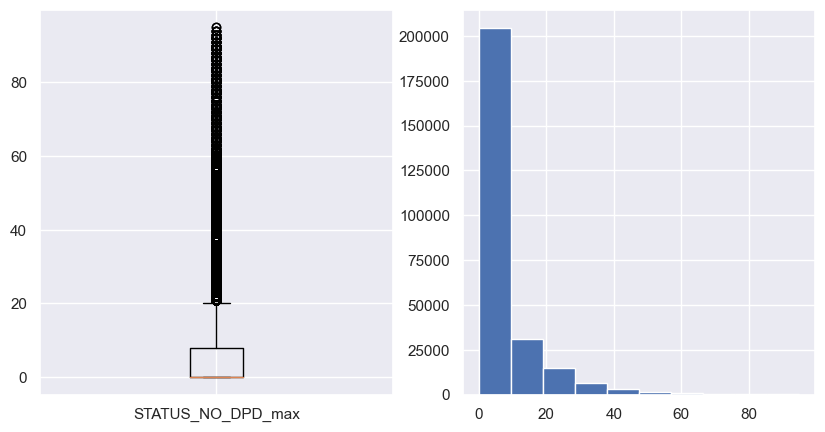

In [98]:
plot_hist_box(numerical_frame, 'STATUS_NO_DPD_max')

Median of STATUS_NO_DPD_max with target=0 : 0.000000
Median of STATUS_NO_DPD_max with target=1 : 0.000000


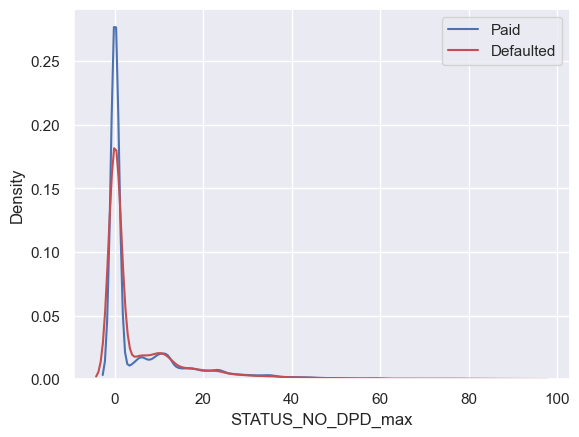

In [99]:
plot_kde_vs_target('STATUS_NO_DPD_max', numerical_frame)
median_vs_target('STATUS_NO_DPD_max', numerical_frame)

(-0.001, 2.0]    7.593708
(2.0, 10.0]      8.953060
(10.0, 18.0]     7.825668
(18.0, 95.0]     7.068636
Name: STATUS_NO_DPD_max_binned, dtype: float64


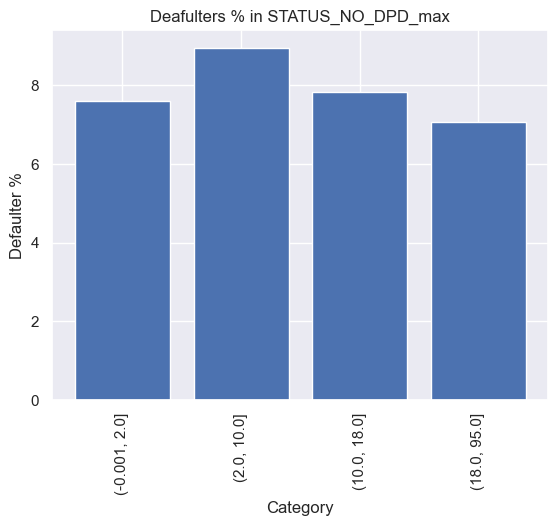

In [100]:
plot_hist_default_pct('STATUS_NO_DPD_max', numerical_frame, 9)

### STATUS_<31DPD_max

In [101]:
numerical_frame['STATUS_<31DPD_max'].isnull().sum()

0

In [102]:
numerical_frame['STATUS_<31DPD_max'].describe()

count    263491.000000
mean          0.312003
std           1.378952
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          56.000000
Name: STATUS_<31DPD_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

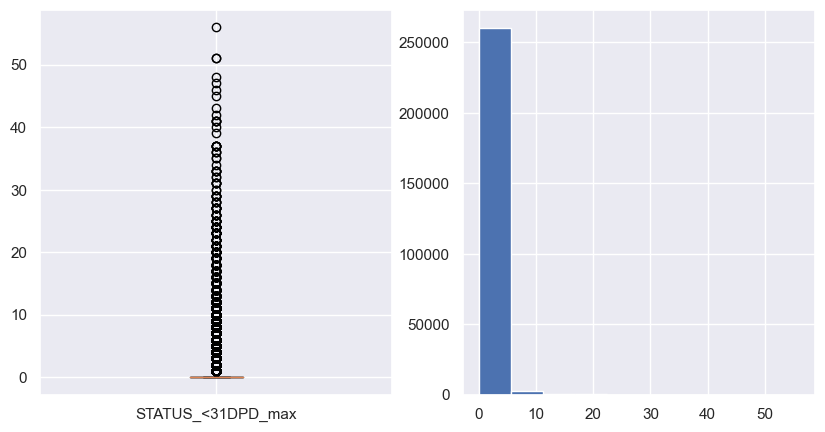

In [103]:
plot_hist_box(numerical_frame, 'STATUS_<31DPD_max')

Median of STATUS_<31DPD_max with target=0 : 0.000000
Median of STATUS_<31DPD_max with target=1 : 0.000000


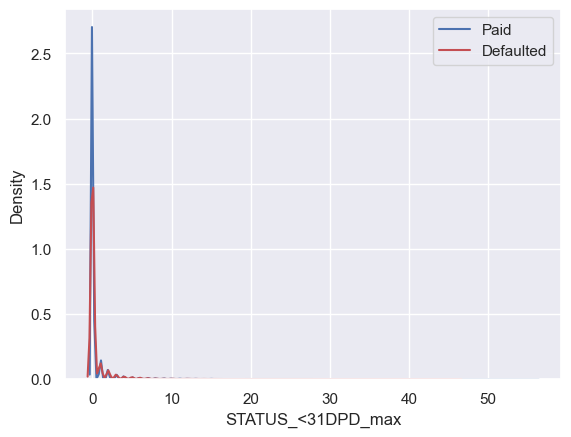

In [104]:
plot_kde_vs_target('STATUS_<31DPD_max', numerical_frame)
median_vs_target('STATUS_<31DPD_max', numerical_frame)

(-0.001, 1.0]     7.533566
(1.0, 56.0]      10.756303
Name: STATUS_<31DPD_max_binned, dtype: float64


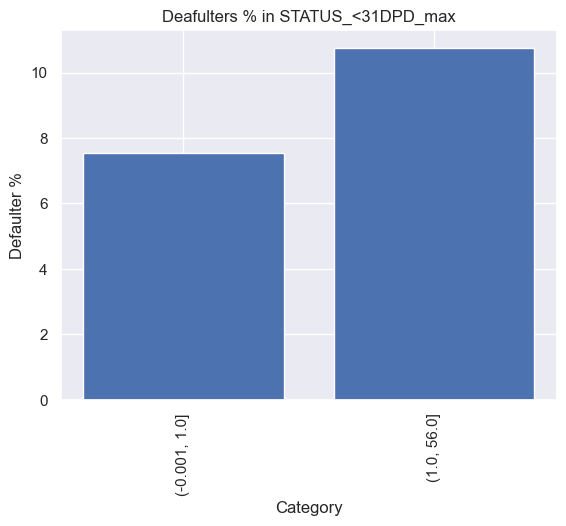

In [105]:
plot_hist_default_pct('STATUS_<31DPD_max', numerical_frame, 9)

### STATUS_<61DPD_max

In [106]:
numerical_frame['STATUS_<61DPD_max'].isnull().sum()

0

In [107]:
numerical_frame['STATUS_<61DPD_max'].describe()

count    263491.000000
mean          0.035978
std           0.311804
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          16.000000
Name: STATUS_<61DPD_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

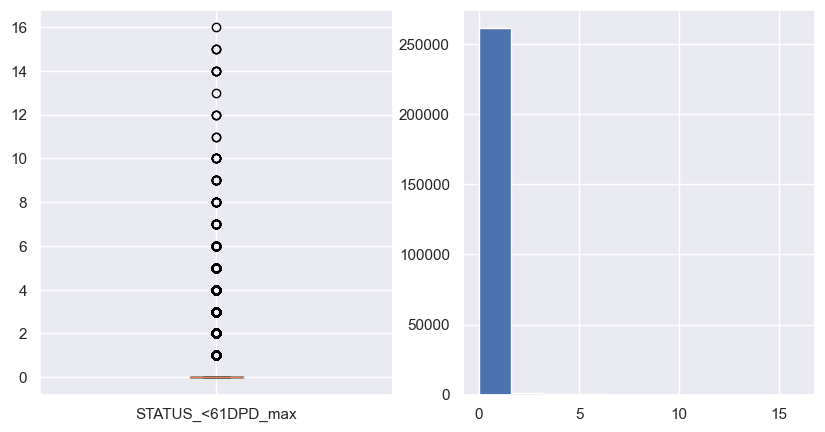

In [108]:
plot_hist_box(numerical_frame, 'STATUS_<61DPD_max')

Median of STATUS_<61DPD_max with target=0 : 0.000000
Median of STATUS_<61DPD_max with target=1 : 0.000000


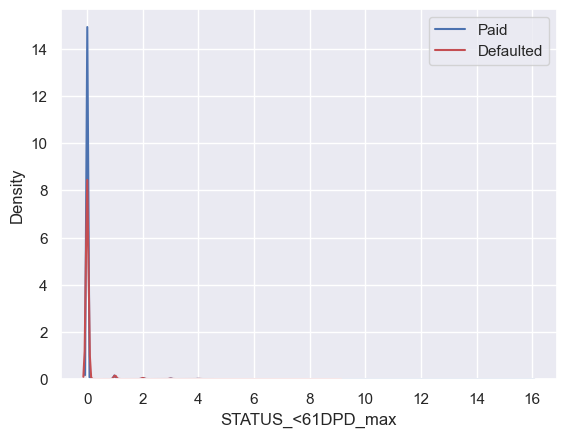

In [109]:
plot_kde_vs_target('STATUS_<61DPD_max', numerical_frame)
median_vs_target('STATUS_<61DPD_max', numerical_frame)

(-0.001, 16.0]    7.730055
Name: STATUS_<61DPD_max_binned, dtype: float64


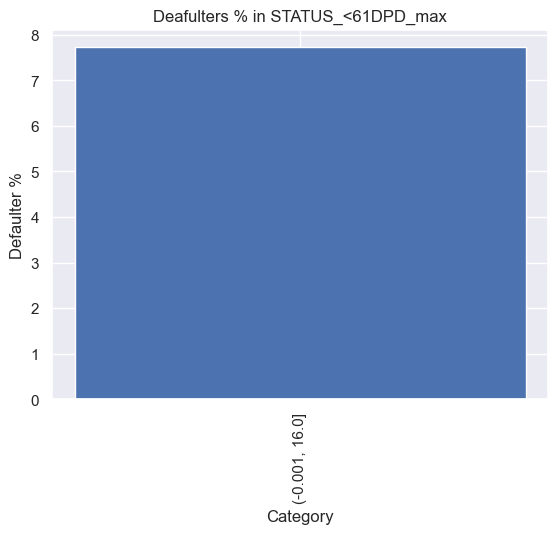

In [110]:
plot_hist_default_pct('STATUS_<61DPD_max', numerical_frame, 9)

### STATUS_CLOSED_max

In [111]:
numerical_frame['STATUS_CLOSED_max'].isnull().sum()

0

In [112]:
numerical_frame['STATUS_CLOSED_max'].describe()

count    263491.000000
mean         10.042138
std          20.391735
min           0.000000
25%           0.000000
50%           0.000000
75%           7.000000
max          96.000000
Name: STATUS_CLOSED_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

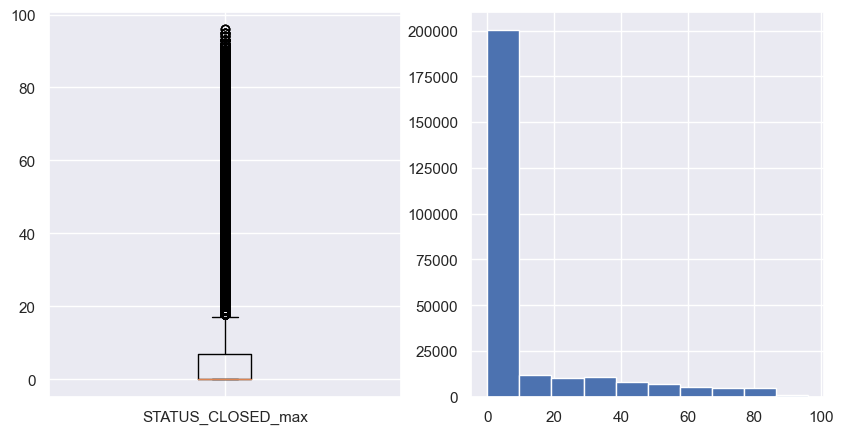

In [113]:
plot_hist_box(numerical_frame, 'STATUS_CLOSED_max')

Median of STATUS_CLOSED_max with target=0 : 0.000000
Median of STATUS_CLOSED_max with target=1 : 0.000000


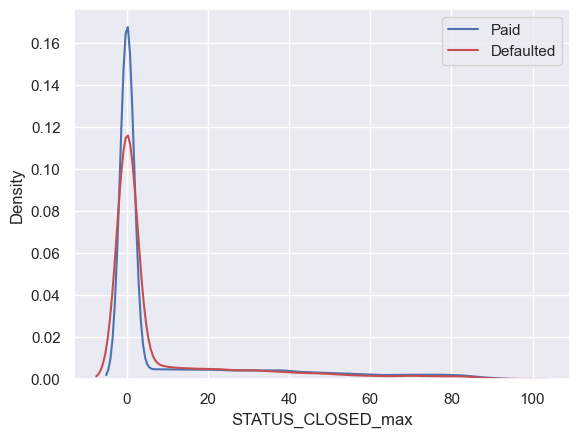

In [114]:
plot_kde_vs_target('STATUS_CLOSED_max', numerical_frame)
median_vs_target('STATUS_CLOSED_max', numerical_frame)

(-0.001, 13.0]    7.939371
(13.0, 39.0]      7.910473
(39.0, 96.0]      6.073723
Name: STATUS_CLOSED_max_binned, dtype: float64


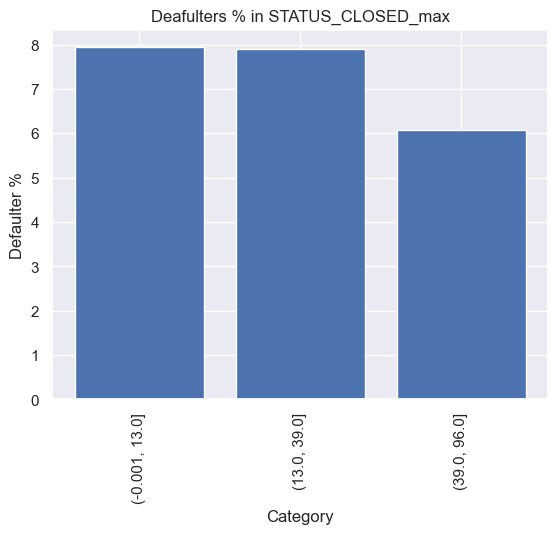

In [115]:
plot_hist_default_pct('STATUS_CLOSED_max', numerical_frame, 9)

### STATUS_TOTAL_max

In [116]:
numerical_frame['STATUS_TOTAL_max'].isnull().sum()

0

In [117]:
numerical_frame['STATUS_TOTAL_max'].describe()

count    263491.000000
mean         15.501345
std          26.439570
min           0.000000
25%           0.000000
50%           0.000000
75%          24.000000
max          97.000000
Name: STATUS_TOTAL_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

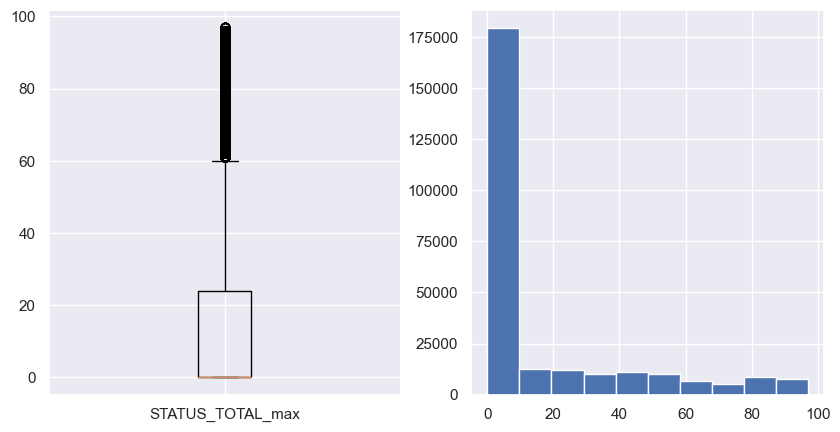

In [118]:
plot_hist_box(numerical_frame, 'STATUS_TOTAL_max')

Median of STATUS_TOTAL_max with target=0 : 0.000000
Median of STATUS_TOTAL_max with target=1 : 0.000000


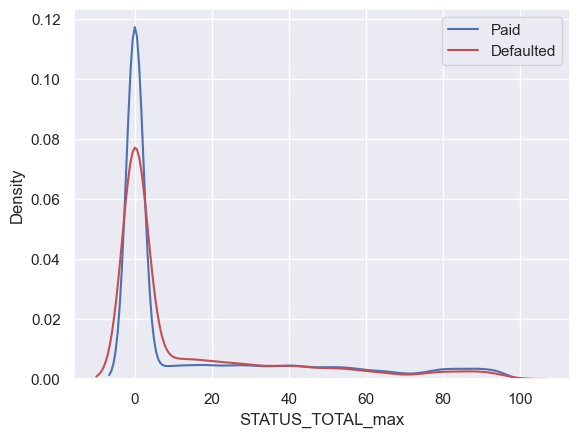

In [119]:
plot_kde_vs_target('STATUS_TOTAL_max', numerical_frame)
median_vs_target('STATUS_TOTAL_max', numerical_frame)

(-0.001, 6.0]    7.657238
(6.0, 30.0]      9.947538
(30.0, 57.0]     7.552181
(57.0, 97.0]     6.073609
Name: STATUS_TOTAL_max_binned, dtype: float64


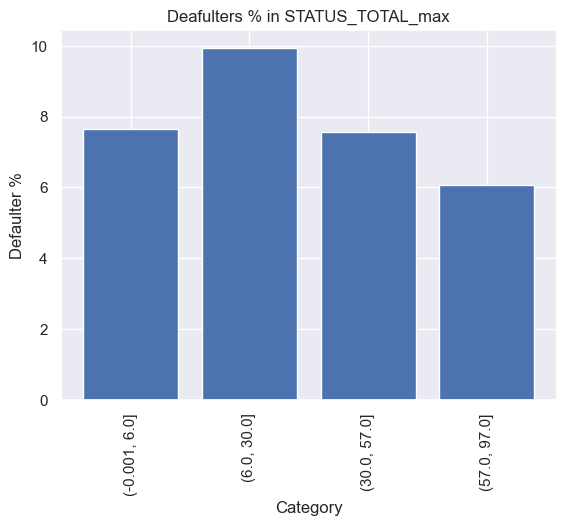

In [120]:
plot_hist_default_pct('STATUS_TOTAL_max', numerical_frame, 9)

### Dropping Unimportant Variables

In [121]:
numerical_frame.columns.sort_values()

Index(['DAYS_CREDIT_ENDDATE_max', 'DAYS_CREDIT_ENDDATE_max_outlier',
       'DAYS_CREDIT_ENDDATE_median', 'DAYS_CREDIT_ENDDATE_median_outlier',
       'DAYS_CREDIT_ENDDATE_min', 'DAYS_CREDIT_ENDDATE_min_outlier',
       'DAYS_CREDIT_UPDATE_median', 'DAYS_CREDIT_UPDATE_median_outlier',
       'DAYS_CREDIT_UPDATE_min', 'DAYS_CREDIT_UPDATE_min_outlier',
       'DAYS_CREDIT_max', 'DAYS_CREDIT_median', 'DAYS_CREDIT_min',
       'DAYS_ENDDATE_FACT_median', 'DAYS_ENDDATE_FACT_min',
       'DAYS_ENDDATE_FACT_min_outlier', 'SK_ID_CURR', 'STATUS_<121DPD_max',
       'STATUS_<31DPD_max', 'STATUS_<61DPD_max', 'STATUS_<91DPD_max',
       'STATUS_CLOSED_max', 'STATUS_NA_max', 'STATUS_NO_DPD_max',
       'STATUS_TOTAL_max', 'TARGET', 'YEARS_CREDIT_ENDDATE_max',
       'YEARS_CREDIT_ENDDATE_median', 'YEARS_CREDIT_ENDDATE_min',
       'YEARS_CREDIT_UPDATE_median', 'YEARS_CREDIT_UPDATE_min',
       'YEARS_CREDIT_max', 'YEARS_CREDIT_median', 'YEARS_CREDIT_min',
       'YEARS_ENDDATE_FACT_median', 'YEARS_

In [122]:
numerical_frame.drop(labels=['YEARS_CREDIT_ENDDATE_max', 'DAYS_CREDIT_ENDDATE_max_outlier', 'DAYS_CREDIT_ENDDATE_max',
                             'DAYS_CREDIT_ENDDATE_median', 'DAYS_CREDIT_ENDDATE_min',
                             'DAYS_CREDIT_UPDATE_median', 'DAYS_CREDIT_UPDATE_min',
                             'DAYS_CREDIT_max', 'DAYS_CREDIT_median', 'DAYS_CREDIT_min',
                             'DAYS_ENDDATE_FACT_median', 'DAYS_ENDDATE_FACT_min',
                             'STATUS_<121DPD_max', 'STATUS_<61DPD_max', 'STATUS_<91DPD_max',
                             'STATUS_CLOSED_max', 'STATUS_NA_max', 'STATUS_NO_DPD_max',
                             'STATUS_TOTAL_max'], axis=1, inplace=True)
numerical_frame.columns.sort_values()

Index(['DAYS_CREDIT_ENDDATE_median_outlier', 'DAYS_CREDIT_ENDDATE_min_outlier',
       'DAYS_CREDIT_UPDATE_median_outlier', 'DAYS_CREDIT_UPDATE_min_outlier',
       'DAYS_ENDDATE_FACT_min_outlier', 'SK_ID_CURR', 'STATUS_<31DPD_max',
       'TARGET', 'YEARS_CREDIT_ENDDATE_median', 'YEARS_CREDIT_ENDDATE_min',
       'YEARS_CREDIT_UPDATE_median', 'YEARS_CREDIT_UPDATE_min',
       'YEARS_CREDIT_max', 'YEARS_CREDIT_median', 'YEARS_CREDIT_min',
       'YEARS_ENDDATE_FACT_median', 'YEARS_ENDDATE_FACT_min'],
      dtype='object')

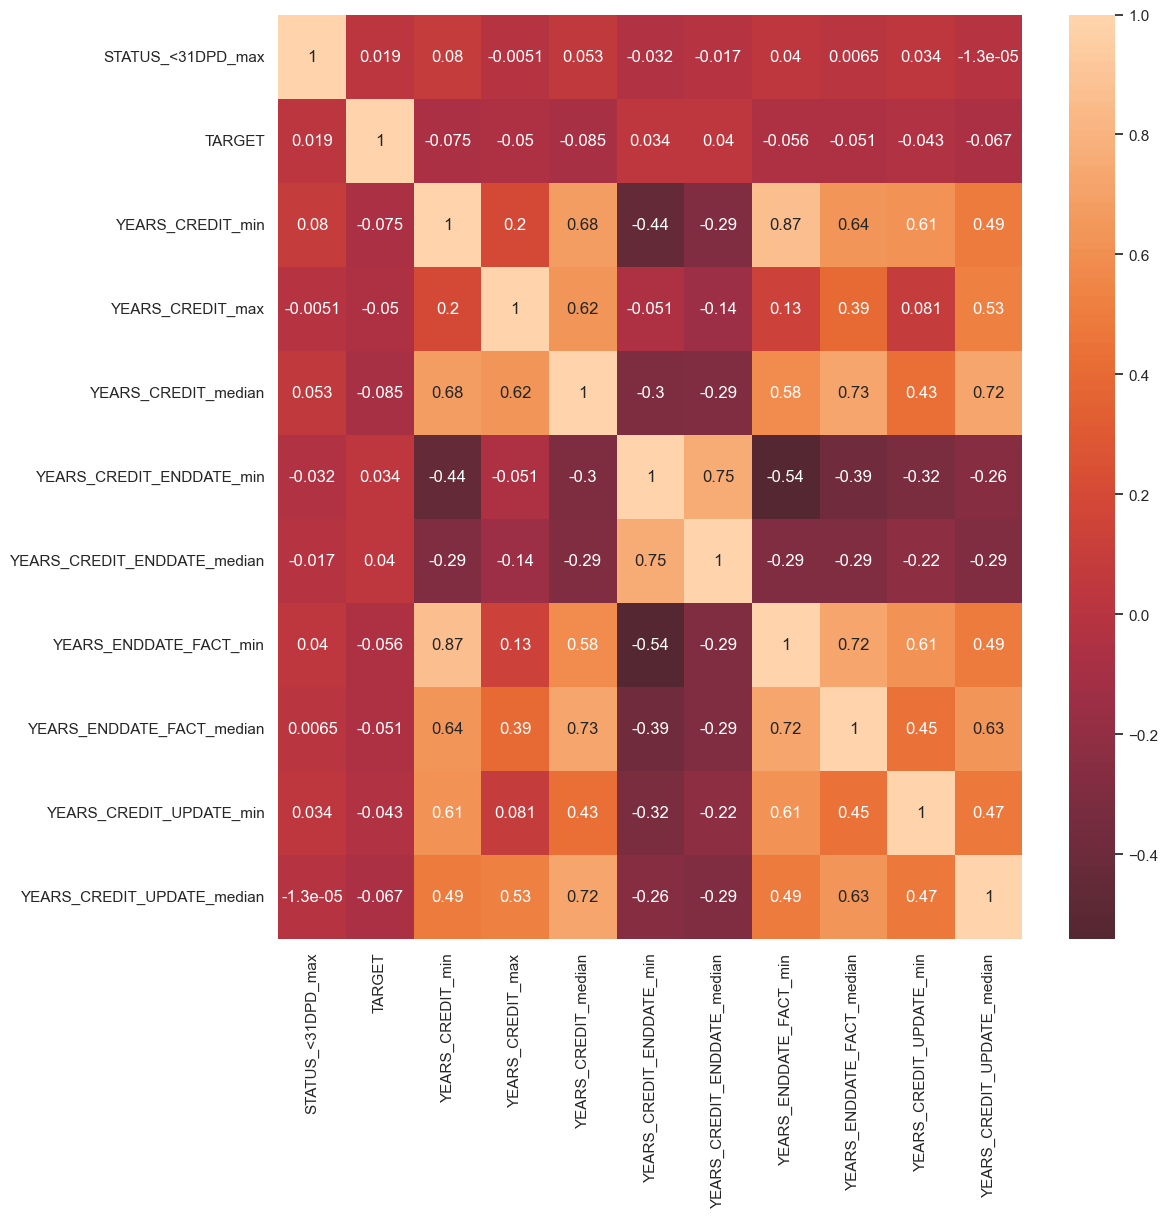

In [123]:
ax=sns.heatmap(numerical_frame.drop(labels=['DAYS_CREDIT_ENDDATE_median_outlier', 'DAYS_CREDIT_ENDDATE_min_outlier',
                                            'DAYS_CREDIT_UPDATE_median_outlier', 'DAYS_CREDIT_UPDATE_min_outlier',
                                            'DAYS_ENDDATE_FACT_min_outlier', 'SK_ID_CURR'], 
                                    axis=1).corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=12, h=12)

## Categorical Data

In [124]:
'''
categorical frame contains bureua data with categorical features
'''
categorical_frame=combined_data[categorical_features].copy()
categorical_frame['SK_ID_CURR']=combined_data['SK_ID_CURR']
categorical_frame['SK_ID_BUREAU']=combined_data['SK_ID_BUREAU']
categorical_frame.columns

Index(['CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE', 'SK_ID_CURR',
       'SK_ID_BUREAU'],
      dtype='object')

In [125]:
categorical_frame.isnull().sum()

CREDIT_ACTIVE      0
CREDIT_CURRENCY    0
CREDIT_TYPE        0
SK_ID_CURR         0
SK_ID_BUREAU       0
dtype: int64

In [126]:
categorical_frame['CREDIT_ACTIVE'].value_counts()

Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: CREDIT_ACTIVE, dtype: int64

In [127]:
categorical_frame['CREDIT_CURRENCY'].value_counts()

currency 1    1715020
currency 2       1224
currency 3        174
currency 4         10
Name: CREDIT_CURRENCY, dtype: int64

#### Functions

In [128]:
def plot_category_vs_target(feature, dataframe):  
    '''
    takes a dataframe and a feature name, plots a chart having pie charts with each pie chart showing the deafult percentage of one of the categories
    '''  
    data=dataframe[feature] #extract the needed column
    values=dataframe[feature].unique() #store the unique values
    values=values[~pd.isna(values)] #store non nan values
    fig, axs=plt.subplots(nrows=values.shape[0])
    fig.set_size_inches(6, 4*values.shape[0])
    for i, value in enumerate(values):
        temp=dataframe[data==value] #extract the needed subset
        total=temp.shape[0]
        plot_data=temp['TARGET'].value_counts()*100/total
        plot_data.rename(index={0: "Paid", 1: "Defaulted"}, inplace=True)
        axs[i].pie(x=plot_data.values, labels=plot_data.index, autopct='%1.1f%%')
        axs[i].set_title("Defaulters in %s"%value)



In [129]:
def plot_category_vs_target_bar(feature, dataframe, ax=None):
    '''
    plots the default percentage of different categories of the variable
    '''
    df=dataframe.copy()
    counts=df[feature].value_counts(dropna=False)
    default_counts=df.loc[df['TARGET']==1, feature].value_counts(dropna=False)
    default_counts=default_counts*100/counts
    default_counts.replace({np.nan: 0}, inplace=True)
    default_counts.sort_values(inplace=True)
    if ax is None:
        ax=plt.axes()
        print(default_counts)
    ax.bar(default_counts.index.astype(str), default_counts.values)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title('Deafulters %% in %s'%feature)
    ax.set_xlabel('Category')
    ax.set_ylabel('Defaulter %')
    return ax

### CREDIT_ACTIVE

In [130]:
'''
this cell aggregates this feature for each current loan.
For each loan and for each category of the feature, total records are counted.
Columns are appropriately changed and nans are replaces
'''
temp_frame=categorical_frame[['SK_ID_CURR', 'CREDIT_ACTIVE']].value_counts().unstack().replace(np.nan, 0).rename(columns=
                                                                                                      lambda x: 'STATUS_'+x.upper()).reset_index()
temp_frame.head()

CREDIT_ACTIVE,SK_ID_CURR,STATUS_ACTIVE,STATUS_BAD DEBT,STATUS_CLOSED,STATUS_SOLD
0,100001,3.0,0.0,4.0,0.0
1,100002,2.0,0.0,6.0,0.0
2,100003,1.0,0.0,3.0,0.0
3,100004,0.0,0.0,2.0,0.0
4,100005,2.0,0.0,1.0,0.0


In [131]:
'''
total column is added
'''
temp_frame['STATUS_TOTAL']=temp_frame.drop('SK_ID_CURR', axis=1).sum(axis=1)
temp_frame.head()

CREDIT_ACTIVE,SK_ID_CURR,STATUS_ACTIVE,STATUS_BAD DEBT,STATUS_CLOSED,STATUS_SOLD,STATUS_TOTAL
0,100001,3.0,0.0,4.0,0.0,7.0
1,100002,2.0,0.0,6.0,0.0,8.0
2,100003,1.0,0.0,3.0,0.0,4.0
3,100004,0.0,0.0,2.0,0.0,2.0
4,100005,2.0,0.0,1.0,0.0,3.0


#### Adding target column

In [132]:
temp_frame=pd.merge(left=temp_frame, right=main_data_id_target, on='SK_ID_CURR', how='inner')
temp_frame.head()

,SK_ID_CURR,STATUS_ACTIVE,STATUS_BAD DEBT,STATUS_CLOSED,STATUS_SOLD,STATUS_TOTAL,TARGET
0,100002,2.0,0.0,6.0,0.0,8.0,1
1,100003,1.0,0.0,3.0,0.0,4.0,0
2,100004,0.0,0.0,2.0,0.0,2.0,0
3,100007,0.0,0.0,1.0,0.0,1.0,0
4,100008,1.0,0.0,2.0,0.0,3.0,0


#### STATUS_ACTIVE

In [133]:
temp_frame['STATUS_ACTIVE'].isnull().sum()

0

In [134]:
temp_frame['STATUS_ACTIVE'].describe()

count    263491.000000
mean          2.056689
std           1.787834
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          32.000000
Name: STATUS_ACTIVE, dtype: float64

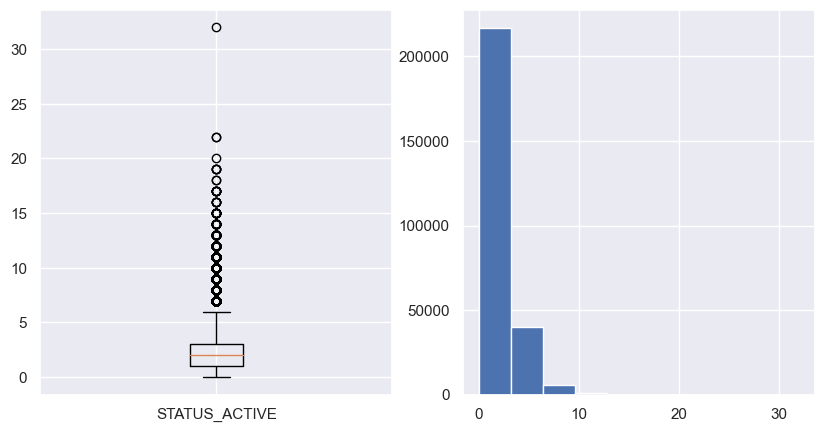

In [135]:
plot_hist_box(temp_frame, 'STATUS_ACTIVE');

Median of STATUS_ACTIVE with target=0 : 2.000000
Median of STATUS_ACTIVE with target=1 : 2.000000


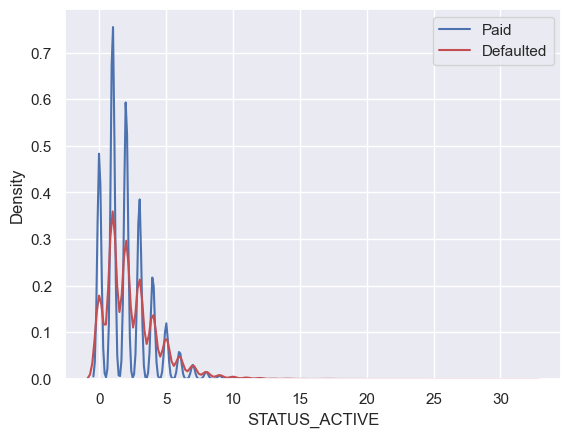

In [136]:
plot_kde_vs_target('STATUS_ACTIVE', temp_frame)
median_vs_target('STATUS_ACTIVE', temp_frame)

(-0.001, 1.0]     6.543290
(1.0, 2.0]        7.443948
(2.0, 3.0]        8.260767
(3.0, 4.0]        9.232793
(4.0, 32.0]      12.051032
Name: STATUS_ACTIVE_binned, dtype: float64


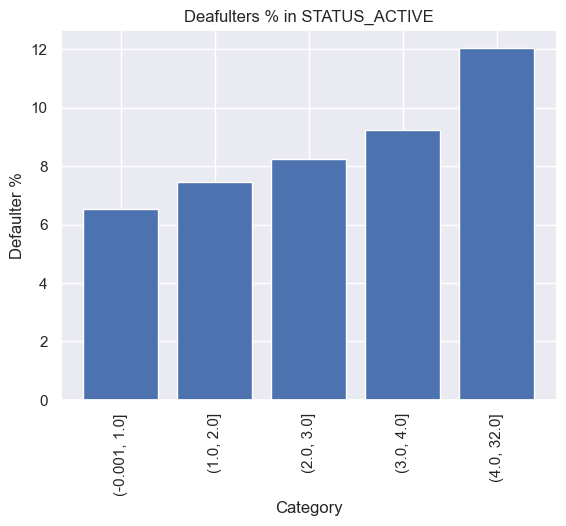

In [137]:
plot_hist_default_pct('STATUS_ACTIVE', temp_frame, 9)

#### STATUS_CLOSED

In [138]:
temp_frame['STATUS_CLOSED'].isnull().sum()

0

In [139]:
temp_frame['STATUS_CLOSED'].describe()

count    263491.000000
mean          3.482977
std           3.381632
min           0.000000
25%           1.000000
50%           3.000000
75%           5.000000
max         108.000000
Name: STATUS_CLOSED, dtype: float64

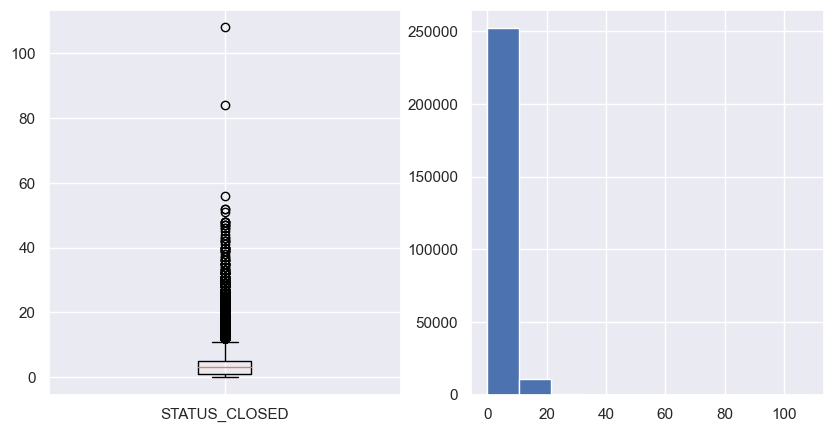

In [140]:
plot_hist_box(temp_frame, 'STATUS_CLOSED');

Median of STATUS_CLOSED with target=0 : 3.000000
Median of STATUS_CLOSED with target=1 : 2.000000


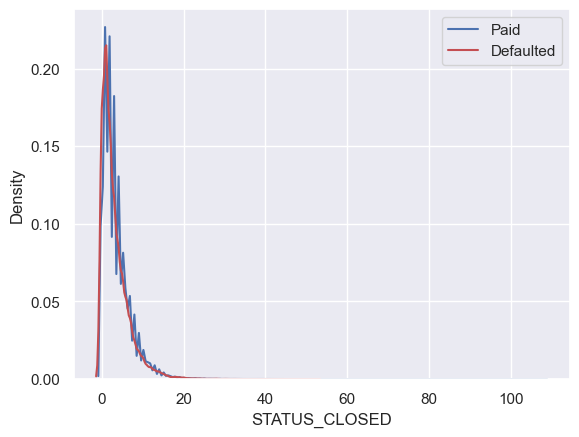

In [141]:
plot_kde_vs_target('STATUS_CLOSED', temp_frame)
median_vs_target('STATUS_CLOSED', temp_frame)

(-0.001, 1.0]    9.403324
(1.0, 2.0]       7.379731
(2.0, 3.0]       6.840120
(3.0, 4.0]       6.629621
(4.0, 5.0]       6.751184
(5.0, 7.0]       6.956794
(7.0, 108.0]     6.593559
Name: STATUS_CLOSED_binned, dtype: float64


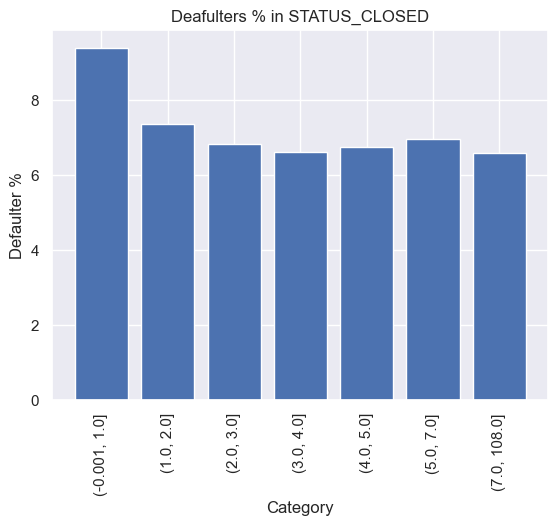

In [142]:
plot_hist_default_pct('STATUS_CLOSED', temp_frame, 9)

#### STATUS_TOTAL

In [143]:
temp_frame['STATUS_TOTAL'].isnull().sum()

0

In [144]:
temp_frame['STATUS_TOTAL'].describe()

count    263491.000000
mean          5.561196
std           4.377897
min           1.000000
25%           2.000000
50%           4.000000
75%           8.000000
max         116.000000
Name: STATUS_TOTAL, dtype: float64

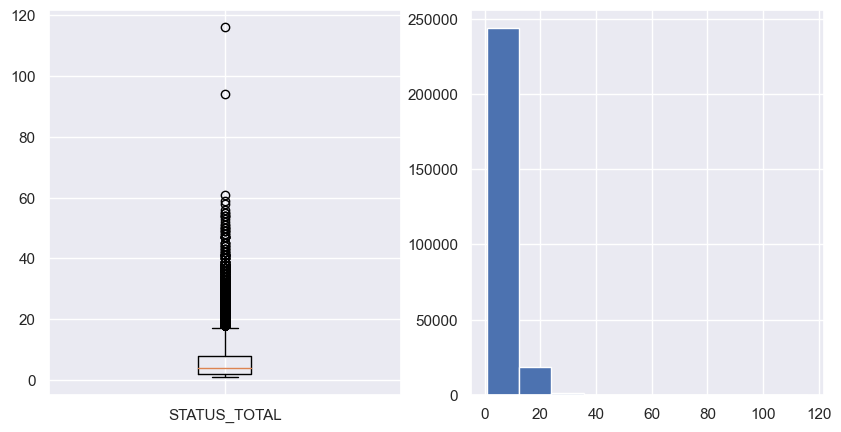

In [145]:
plot_hist_box(temp_frame, 'STATUS_TOTAL');

Median of STATUS_TOTAL with target=0 : 4.000000
Median of STATUS_TOTAL with target=1 : 4.000000


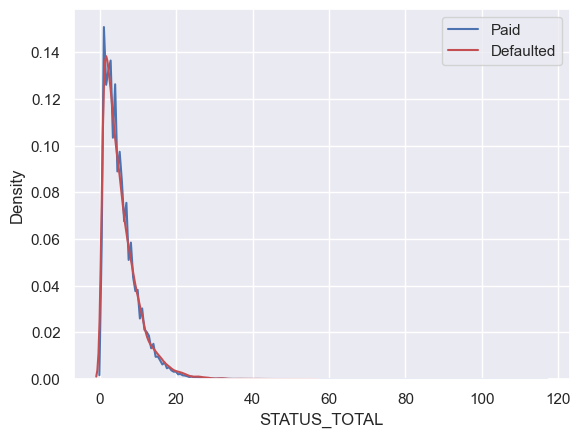

In [146]:
plot_kde_vs_target('STATUS_TOTAL', temp_frame)
median_vs_target('STATUS_TOTAL', temp_frame)

(0.999, 2.0]     8.202825
(2.0, 3.0]       7.608200
(3.0, 4.0]       7.127325
(4.0, 5.0]       7.444467
(5.0, 6.0]       7.206949
(6.0, 8.0]       7.354011
(8.0, 11.0]      7.926426
(11.0, 116.0]    8.217048
Name: STATUS_TOTAL_binned, dtype: float64


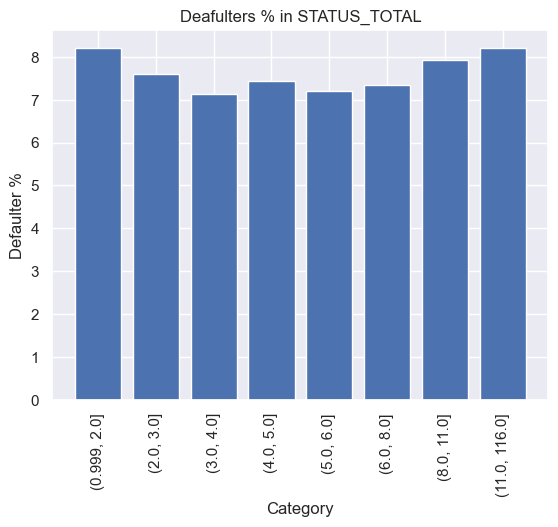

In [147]:
plot_hist_default_pct('STATUS_TOTAL', temp_frame, 9)

#### STATUS_ACTIVE_PCT (mi)

In [148]:
temp_frame['STATUS_ACTIVE_PCT']=temp_frame['STATUS_ACTIVE']*100/temp_frame['STATUS_TOTAL']
temp_frame['STATUS_ACTIVE_PCT'].isnull().sum()

0

In [149]:
temp_frame['STATUS_ACTIVE_PCT'].describe()

count    263491.000000
mean         41.297189
std          30.840438
min           0.000000
25%          20.000000
50%          37.500000
75%          60.000000
max         100.000000
Name: STATUS_ACTIVE_PCT, dtype: float64

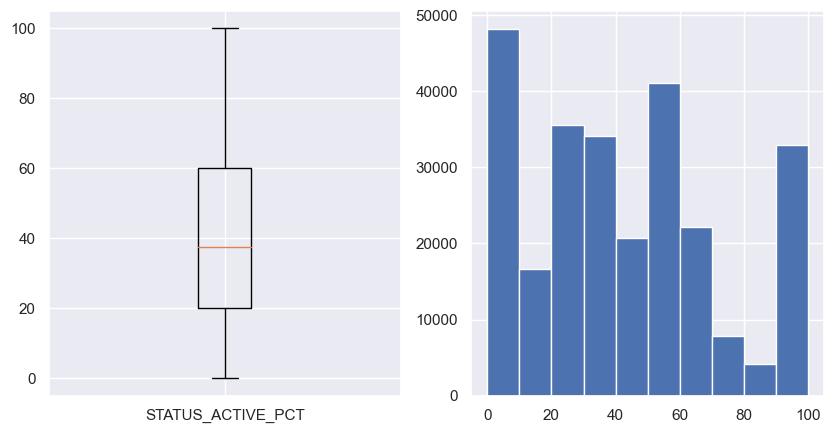

In [150]:
plot_hist_box(temp_frame, 'STATUS_ACTIVE_PCT');

Median of STATUS_ACTIVE_PCT with target=0 : 36.363636
Median of STATUS_ACTIVE_PCT with target=1 : 50.000000


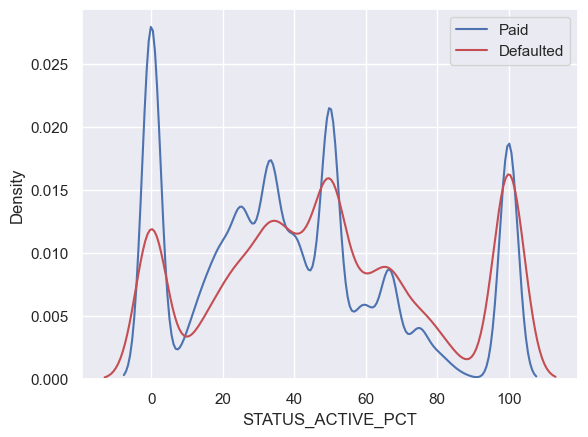

In [151]:
plot_kde_vs_target('STATUS_ACTIVE_PCT', temp_frame)
median_vs_target('STATUS_ACTIVE_PCT', temp_frame)

(-0.001, 16.667]     5.464124
(16.667, 25.0]       5.565419
(25.0, 33.333]       6.425230
(33.333, 42.857]     7.680304
(42.857, 50.0]       8.252171
(50.0, 66.667]      10.062019
(66.667, 100.0]     11.422036
Name: STATUS_ACTIVE_PCT_binned, dtype: float64


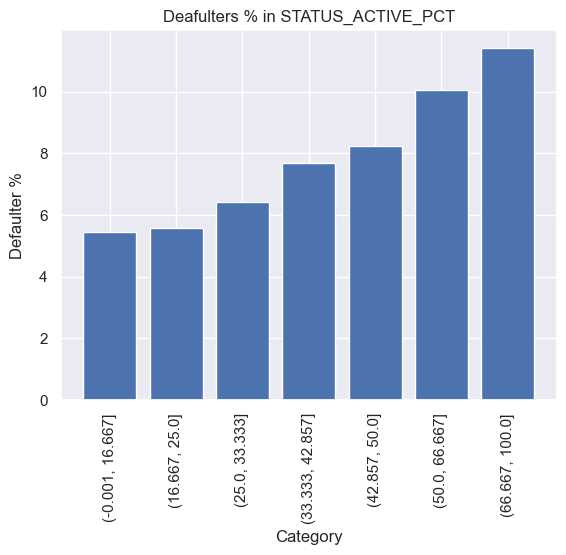

In [152]:
plot_hist_default_pct('STATUS_ACTIVE_PCT', temp_frame, 9)

#### STATUS_CLOSED_PCT

In [153]:
temp_frame['STATUS_CLOSED_PCT']=temp_frame['STATUS_CLOSED']*100/temp_frame['STATUS_TOTAL']
temp_frame['STATUS_CLOSED_PCT'].isnull().sum()

0

In [154]:
temp_frame['STATUS_CLOSED_PCT'].describe()

count    263491.000000
mean         58.311216
std          30.867987
min           0.000000
25%          40.000000
50%          62.500000
75%          80.000000
max         100.000000
Name: STATUS_CLOSED_PCT, dtype: float64

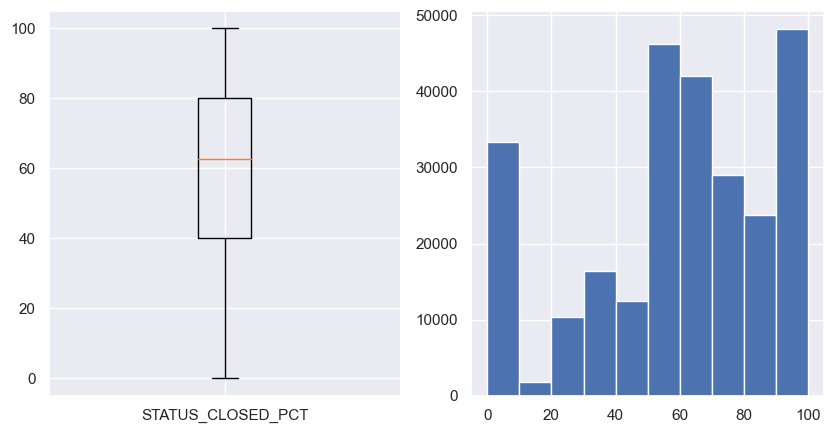

In [155]:
plot_hist_box(temp_frame, 'STATUS_CLOSED_PCT');

Median of STATUS_CLOSED_PCT with target=0 : 62.500000
Median of STATUS_CLOSED_PCT with target=1 : 50.000000


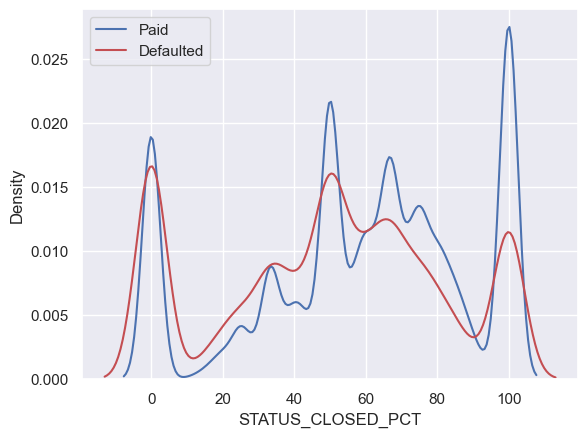

In [156]:
plot_kde_vs_target('STATUS_CLOSED_PCT', temp_frame)
median_vs_target('STATUS_CLOSED_PCT', temp_frame)

(-0.001, 33.333]    11.026680
(33.333, 50.0]       8.646323
(50.0, 57.143]       9.268548
(57.143, 66.667]     6.965031
(66.667, 75.0]       5.959032
(75.0, 83.333]       5.271203
(83.333, 100.0]      5.426041
Name: STATUS_CLOSED_PCT_binned, dtype: float64


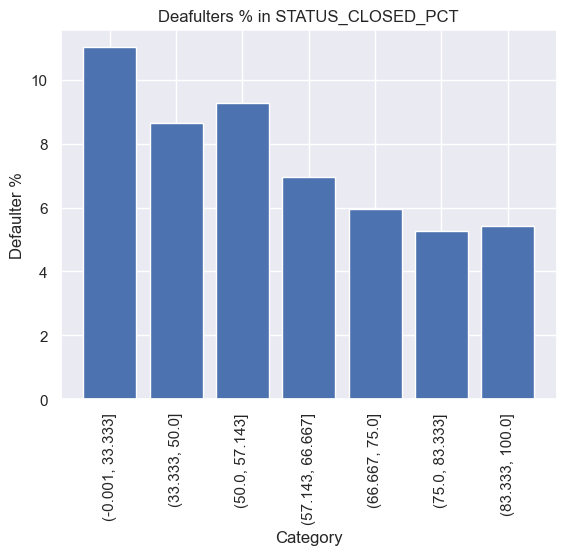

In [157]:
plot_hist_default_pct('STATUS_CLOSED_PCT', temp_frame, 9)

### Dropping Unimportant Variables

In [158]:
temp_frame.columns.sort_values()

Index(['SK_ID_CURR', 'STATUS_ACTIVE', 'STATUS_ACTIVE_PCT', 'STATUS_BAD DEBT',
       'STATUS_CLOSED', 'STATUS_CLOSED_PCT', 'STATUS_SOLD', 'STATUS_TOTAL',
       'TARGET'],
      dtype='object')

In [159]:
temp_frame.drop(axis=1, labels=['STATUS_BAD DEBT', 'STATUS_CLOSED', 'STATUS_SOLD', 'STATUS_TOTAL'], inplace=True)
temp_frame.columns.sort_values()

Index(['SK_ID_CURR', 'STATUS_ACTIVE', 'STATUS_ACTIVE_PCT', 'STATUS_CLOSED_PCT',
       'TARGET'],
      dtype='object')

#### Further Filtering

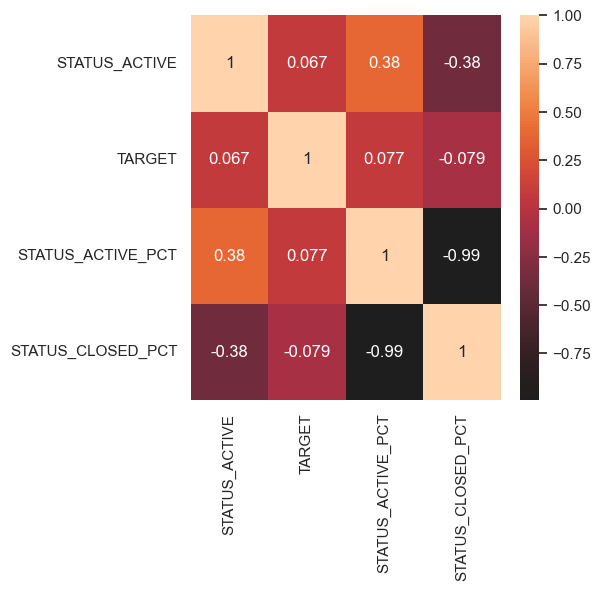

In [160]:
ax=sns.heatmap(temp_frame.drop('SK_ID_CURR', axis=1).corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=5, h=5)

In [161]:
temp_frame.drop(axis=1, labels=['STATUS_CLOSED_PCT'], inplace=True)
temp_frame.columns

Index(['SK_ID_CURR', 'STATUS_ACTIVE', 'TARGET', 'STATUS_ACTIVE_PCT'], dtype='object')

## Merging numerical and categorical aggregated data

In [173]:
initial_clean_bureau=pd.merge(left=numerical_frame, right=temp_frame, on=['SK_ID_CURR', 'TARGET'])
initial_clean_bureau.columns.sort_values(), initial_clean_bureau.shape

(Index(['DAYS_CREDIT_ENDDATE_median_outlier', 'DAYS_CREDIT_ENDDATE_min_outlier',
        'DAYS_CREDIT_UPDATE_median_outlier', 'DAYS_CREDIT_UPDATE_min_outlier',
        'DAYS_ENDDATE_FACT_min_outlier', 'SK_ID_CURR', 'STATUS_<31DPD_max',
        'STATUS_ACTIVE', 'STATUS_ACTIVE_PCT', 'TARGET',
        'YEARS_CREDIT_ENDDATE_median', 'YEARS_CREDIT_ENDDATE_min',
        'YEARS_CREDIT_UPDATE_median', 'YEARS_CREDIT_UPDATE_min',
        'YEARS_CREDIT_max', 'YEARS_CREDIT_median', 'YEARS_CREDIT_min',
        'YEARS_ENDDATE_FACT_median', 'YEARS_ENDDATE_FACT_min'],
       dtype='object'),
 (263491, 19))

In [174]:
initial_clean_bureau.to_csv('initial_clean_bureau.csv', index=False)